# Generate data for the simplified TEP case

## Setup Instructions

1. **Install Miniconda** (or Anaconda) by following the official installation guide:
   https://www.anaconda.com/docs/getting-started/installation

2. **Create a conda virtual environment** from the provided environment file:

   ```bash
   conda env create -f env.yml (Linux)
   conda env create -f env_windows (Windows)

This will create an environment named WorkShopEnv (as defined in env.yml) with all the required dependencies.


3. **Activate the environment before use:**

    ```bash
    conda activate WorkShopEnv


### Using with Jupyter Notebook

Once the environment is created, you can use it as the kernel in Jupyter Notebook:

- Open your notebook in Jupyter

- Click on the kernel selector in the top-right corner (it may say "Python 3" or similar)

- Select WorkShopEnv from the list of available kernels

- If the environment does not appear automatically, you may need to install the IPython kernel first:

    ```bash
    conda activate WorkShopEnv
    python -m ipykernel install --user --name WorkShopEnv --display-name "WorkShopEnv"

## Import necessary codes and packages

In [1]:
#Let us reload all the files that were modified without restarting the kernel and running back all the cells  
%reload_ext autoreload                                                                                                                                                          
%autoreload 2 

from TEPlant import TEParams, TEPlant # Numpy plant implementation
from TorchTEPlant import TorchTEPlant # PyTorch plant implementation
from closed_loop_scenarios import run_closed_loop_scenario, _SCENARIOS # Numpy closed-loop scenario
from plot_utils import plotly_scenario_comparison
from integrators import *

import torch
from torch.linalg import cholesky
from torchdr import TSNE

import random
import numpy as np
from scipy.stats import qmc

from plotly import graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

## Generating data from NumPy closed-loop scenarios

Let's first define sampling time, closed-loop scenarios and initialize (X, U) and Y tensors. You can find the definition of X, U and Y variables in the paper of Ricker et al. on the workshop SharePoint [here](https://cenaero.sharepoint.com/:b:/r/sites/ARIAC/Documents%20partages/TRAIL-Challenges/Challenge2_Energy/TRAIL-Workshop2026/TEP_use_case/Papers/Ricker_Model_Predictive_Control_of_a_continuous_nonlinear_two_phase_reactor_1993.pdf?d=w92660b6188484a26acaa70c63eea58a8&csf=1&web=1&e=DPMmcp).

In [18]:
dt = 0.1
scenarios = tuple(x for x in _SCENARIOS if x not in ['kinetic_drift', 'nominal'])

X_U_scen = torch.zeros([0, 2, 12]) # Tensor which contains X and U
Y_scen   = torch.zeros([0, 2, 10]) # Tensor which contains Y
COLORS_scen = torch.zeros([0]) # init colors tensor for TSNE graph

scenarios

('feed_A_composition',
 'feed_B_composition',
 'loss_f2',
 'ramp_production',
 'low_cost_ya3')

Now we will generate closed-loop data with NumPy code (closed-loop code translated in pytorch will arrive soon). The data obtained will serve as reference to find the data domain where we can generate open-loop data.

In [19]:
scenarios_dict = {}

for idx, scenario in enumerate(scenarios) :
    
    TE_RESULTS = run_closed_loop_scenario(scenario = scenario, dt = dt)
    scenarios_dict[scenario] = TE_RESULTS

    PARAMS = TE_RESULTS['params']
    NP_PLANT = TEPlant(params = PARAMS)

    # Convert into PyTorch
    X_U = torch.cat((torch.from_numpy(TE_RESULTS['x'].T), torch.from_numpy(TE_RESULTS['u'].T)), dim = -1)
    Y = torch.from_numpy(TE_RESULTS['y'].T)

    X_U_scen    = torch.cat((X_U_scen, torch.stack((X_U[:-1], X_U[1:]), dim = 1)), dim = 0)
    Y_scen      = torch.cat((Y_scen, torch.stack((Y[:-1], Y[1:]), dim = 1)), dim = 0)
    COLORS_scen = torch.cat((COLORS_scen, torch.full((X_U.size(0) - 1,), fill_value = idx + 1)))

In [20]:
X_U_scen

tensor([[[44.5000, 13.5330, 36.6479,  ..., 25.0223, 39.2578, 44.1767],
         [43.8483, 13.5330, 37.4009,  ..., 25.0223, 39.9879, 44.1767]],

        [[43.8483, 13.5330, 37.4009,  ..., 25.0223, 39.9879, 44.1767],
         [43.2784, 13.5313, 38.2261,  ..., 26.5612, 41.8568, 44.1767]],

        [[43.2784, 13.5313, 38.2261,  ..., 26.5612, 41.8568, 44.1767],
         [42.7869, 13.5250, 39.0861,  ..., 28.0901, 44.6184, 44.1767]],

        ...,

        [[59.3632, 19.9549, 15.4276,  ..., 32.1887, 26.7760, 44.1767],
         [59.3668, 19.9524, 15.4250,  ..., 32.2023, 26.7934, 44.1767]],

        [[59.3668, 19.9524, 15.4250,  ..., 32.2023, 26.7934, 44.1767],
         [59.3706, 19.9498, 15.4223,  ..., 32.2153, 26.8100, 44.1767]],

        [[59.3706, 19.9498, 15.4223,  ..., 32.2153, 26.8100, 44.1767],
         [59.3744, 19.9472, 15.4196,  ..., 32.2153, 26.8100, 44.1767]]],
       dtype=torch.float64)

Display the different closed-loop scenarios

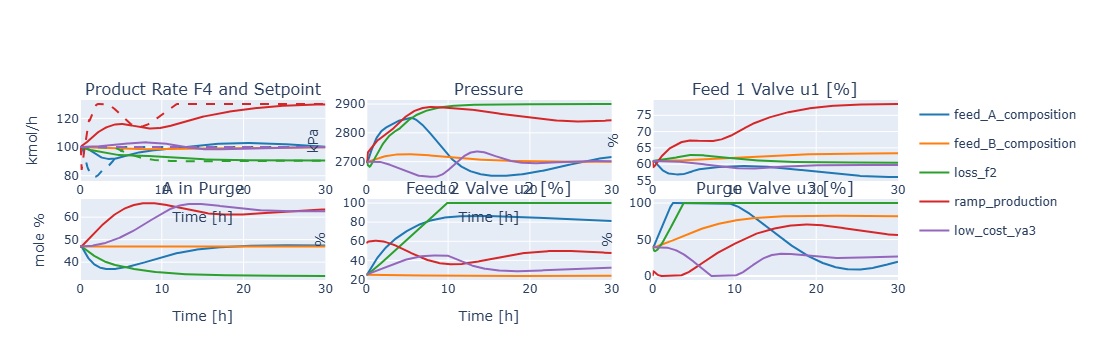

In [21]:
fig = plotly_scenario_comparison(scenarios_dict)
fig

## Generating open-loop data based on data distribution from closed-loop scenarios

### First example

We will first compute closed-loop data statistics to have the average and covariance of the X, U data distribution

In [22]:
X_U_MEAN = X_U_scen[:, 0].mean(dim = 0) # average
X_U_COV  = X_U_scen[:, 0].transpose(dim0 = 0, dim1 = 1).cov() # covariance

print(X_U_MEAN)
print(X_U_COV.size())

tensor([ 48.1535,  13.1277,  35.7316, 110.9264,  62.8059,  36.5615,  58.4889,
         47.5510,  62.8148,  54.0262,  58.6153,  44.1767], dtype=torch.float64)
torch.Size([12, 12])


Now we will **generate** `n_samples` random (X0, U0) **initial conditions with Multivariate Gaussian** ([explaination here](https://www.youtube.com/watch?v=azrTdjrA2bU))  by transforming standard normal samples using the Cholesky decomposition ([explaination here](https://www.statlect.com/matrix-algebra/Cholesky-decomposition)) of the covariance matrix (to induce the correct correlations between states x and inputs u) and adding the mean vector. 

The last control, u4 is set to a constant mean value since it was originally controlled by a level controller in closed-loop scenario so it is not an independent (manipulated) control variable. 

In [23]:
def generate_initial_conditions_gaussian(n_samples: int, x_u_mean: Tensor, x_u_cov: Tensor) -> tuple[Tensor, Tensor]:
    # Sample first 11 variables (8 states + 3 controls) with multivariate normal distribution
    X_U0 = x_u_mean[:11][None, :] + (cholesky(x_u_cov[:11, :11])[None, :, :] @
                                    torch.randn((n_samples, 11), dtype = x_u_mean.dtype)[:, :, None]).squeeze(-1)
    # Add u4 as constant value since it is just a setpoint kept constant in closed-loop scenarios
    X_U0 = torch.cat((X_U0, torch.full((n_samples, 1), x_u_mean[11])), dim = -1)
    # Separate X0 and U0
    X0, U0 = X_U0[:, :8], X_U0[:, 8:]
    # Clip initial conditions to physical ranges
    X0[:, :4] = torch.clamp(X0[:, :4], min=1e-8) # Ensure non-zero positive mole counts for stability of the system
    X0[:, 4:8] = torch.clamp(X0[:, 4:8], min=0.0, max=100.0) # Ensure valve positions are valid
    U0[:, :3] = torch.clamp(U0[:, :3], min=0.0, max=100.0) # Ensure valve controls are valid

    return X0, U0

In [24]:
n_samples = int(3000)

X0, U0 = generate_initial_conditions_gaussian(n_samples, X_U_MEAN, X_U_COV)

print("X initial conditions", X0)
print("U initial conditions", U0)
print("Tensor sizes", X0.size(), U0.size())

X initial conditions tensor([[49.2380, 17.2890, 35.4930,  ...,  0.0000, 65.7116, 42.7713],
        [47.4844, 14.6219, 32.4944,  ..., 52.1572, 58.0734, 48.6106],
        [39.5560,  8.2940, 49.1122,  ..., 49.1453, 73.4139, 43.4952],
        ...,
        [41.8708,  9.8098, 45.3471,  ..., 43.9075, 58.7739, 48.0714],
        [35.5652,  8.9974, 50.4492,  ..., 46.7198, 81.9077, 44.2014],
        [42.2539,  8.9011, 47.1709,  ..., 51.5041, 78.9928, 47.5935]],
       dtype=torch.float64)
U initial conditions tensor([[63.1063, 46.7820, 64.6166, 44.1767],
        [63.1062, 35.3214, 57.7501, 44.1767],
        [56.8437, 67.5210, 72.9137, 44.1767],
        ...,
        [62.8470, 66.8489, 59.6897, 44.1767],
        [58.1867, 57.4605, 82.4578, 44.1767],
        [63.4873, 71.5573, 78.4103, 44.1767]], dtype=torch.float64)
Tensor sizes torch.Size([3000, 8]) torch.Size([3000, 4])


In [9]:
X0

tensor([[ 52.0189,  17.3162,  26.0148,  ...,  23.4034,  15.3920,  44.6700],
        [ 45.0445,  10.8525,  38.0910,  ...,  63.4837,  99.1197,  50.7810],
        [ 45.9010,  10.8589,  43.6353,  ...,   0.0000, 100.0000,  50.7336],
        ...,
        [ 56.4400,  16.8592,  19.3932,  ...,  55.1483,  43.4236,  55.1106],
        [ 43.3135,  16.8902,  37.1734,  ...,  20.7067,  77.1297,  39.1637],
        [ 30.2779,  12.6089,  54.6179,  ...,   0.0000,  77.0950,  35.3748]],
       dtype=torch.float64)

In [10]:
U0

tensor([[ 56.5602,  42.6357,  14.0523,  44.1767],
        [ 66.3926,  33.7796,  98.5451,  44.1767],
        [ 75.8310,  28.9461, 100.0000,  44.1767],
        ...,
        [ 69.9847,  14.0830,  43.5929,  44.1767],
        [ 53.0449,  36.8854,  76.0003,  44.1767],
        [ 50.2626,  52.5363,  76.5649,  44.1767]], dtype=torch.float64)

Let's generate the next state X1 by integrating initial conditions by batch thanks to PyTorch ! 

In [25]:
def generate_data_couples(x0: Tensor, u0: Tensor, params: TEParams = TEParams(), 
                          batch_size: int = 500) -> tuple[Tensor, Tensor, Tensor] :
    """
    Generate data couples (x0, u0) -> (x1, u0) by integrating plant dynamics. 
    Control u is kept constant (u0) during the integration step.
    
    Args:
        x0: Initial states of shape (n_samples, 8)
        u0: Control inputs of shape (n_samples, 4)
        params: TEParams for plant dynamics
        batch_size: Batch size for integration
    
    Returns:
        X_U_rand: Stack of (x0, u0) and (x1, u0) of shape (n_samples, 2, 12)
        Y_rand: Outputs at t0 and t1 of shape (n_samples, 2, 10)
        COLORS_rand: Color labels of shape (n_samples,) as Tensor
    """
    
    PLANT = TorchTEPlant(params = params)

    X1 = torch.zeros_like(x0)
    Y_rand = torch.zeros([x0.size(0), 2, 10])
    TIME_SPAN = torch.tensor([[0, dt]]).expand([x0.size(0), 2])

    for batch_idx in range((x0.size(0) + batch_size - 1) // batch_size):

        start_idx, end_idx = batch_idx * batch_size, (batch_idx + 1) * batch_size
        PLANT.reset_memory(x=x0[start_idx:end_idx])

        # Integrate to get X1
        X1[start_idx:end_idx] = integrate_wcontrol(PLANT.derivatives, 
                                                x0[start_idx:end_idx],
                                                TIME_SPAN[start_idx:end_idx],
                                                u0[start_idx:end_idx])[:, -1]
        
        # Compute outputs Y0, Y1 for this batch
        Y_rand[start_idx:end_idx, 0] = PLANT.outputs(TIME_SPAN[start_idx:end_idx, 0], 
                                                    x0[start_idx:end_idx], 
                                                    u0[start_idx:end_idx])

        Y_rand[start_idx:end_idx, 1] = PLANT.outputs(TIME_SPAN[start_idx:end_idx, 1], 
                                                    X1[start_idx:end_idx], 
                                                    u0[start_idx:end_idx])

    X_U_rand = torch.stack((torch.cat((x0, u0), dim = -1), torch.cat((X1, u0), dim = -1)), dim = 1)
    COLORS_rand = torch.zeros((X_U_rand.size(0),))

    return X_U_rand, Y_rand, COLORS_rand

In [26]:
X_U_rand, Y_rand, COLORS_rand = generate_data_couples(X0, U0, batch_size=500)

print(X_U_rand[:, 0].mean(dim = 1))
print(X_U_rand[:, 0].std(dim = 1))


print(X_U_scen[:, 0].mean(dim = 1))
print(X_U_scen[:, 0].std(dim = 1))

print(X_U_rand.size())
print(Y_rand.size())

tensor([49.5592, 52.4676, 55.4081,  ..., 54.6777, 56.0993, 59.0576],
       dtype=torch.float64)
tensor([25.9850, 23.6623, 23.2231,  ..., 23.6025, 24.8690, 25.2556],
       dtype=torch.float64)
tensor([45.5295, 45.5924, 45.9384,  ..., 44.4390, 44.4443, 44.4495],
       dtype=torch.float64)
tensor([24.6056, 24.5570, 24.3391,  ..., 25.8572, 25.8548, 25.8525],
       dtype=torch.float64)
torch.Size([3000, 2, 12])
torch.Size([3000, 2, 10])


In [13]:
X_U_rand

tensor([[[ 52.0189,  17.3162,  26.0148,  ...,  42.6357,  14.0523,  44.1767],
         [ 51.5768,  17.3634,  25.1642,  ...,  42.6357,  14.0523,  44.1767]],

        [[ 45.0445,  10.8525,  38.0910,  ...,  33.7796,  98.5451,  44.1767],
         [ 45.1669,  10.7589,  38.1168,  ...,  33.7796,  98.5451,  44.1767]],

        [[ 45.9010,  10.8589,  43.6353,  ...,  28.9461, 100.0000,  44.1767],
         [ 46.4572,  10.7852,  44.2271,  ...,  28.9461, 100.0000,  44.1767]],

        ...,

        [[ 56.4400,  16.8592,  19.3932,  ...,  14.0830,  43.5929,  44.1767],
         [ 56.8022,  16.8336,  20.3002,  ...,  14.0830,  43.5929,  44.1767]],

        [[ 43.3135,  16.8902,  37.1734,  ...,  36.8854,  76.0003,  44.1767],
         [ 42.6597,  16.7395,  36.2284,  ...,  36.8854,  76.0003,  44.1767]],

        [[ 30.2779,  12.6089,  54.6179,  ...,  52.5363,  76.5649,  44.1767],
         [ 31.7008,  12.5151,  54.9732,  ...,  52.5363,  76.5649,  44.1767]]],
       dtype=torch.float64)

In [14]:
Y_rand

tensor([[[1.8693e+02, 5.2564e+00, 2.7661e+00,  ..., 1.8161e+01,
          2.7284e+01, 8.4024e-02],
         [1.8691e+02, 9.5555e+00, 2.5104e+00,  ..., 1.8161e+01,
          2.7284e+01, 7.6009e-02]],

        [[2.1927e+02, 1.4258e+01, 1.7791e+01,  ..., 1.1547e+01,
          4.0528e+01, 5.8667e-01],
         [2.1940e+02, 7.6017e+00, 1.7690e+01,  ..., 1.1547e+01,
          4.0528e+01, 5.8538e-01]],

        [[2.5049e+02, 0.0000e+00, 1.8573e+01,  ..., 1.0816e+01,
          4.3464e+01, 6.1451e-01],
         [2.5059e+02, 6.4991e+00, 1.8609e+01,  ..., 1.0816e+01,
          4.3464e+01, 6.1110e-01]],

        ...,

        [[2.3141e+02, 1.2386e+01, 7.7730e+00,  ..., 1.8188e+01,
          2.0922e+01, 1.7530e-01],
         [2.3127e+02, 3.1645e+00, 7.8531e+00,  ..., 1.8188e+01,
          2.0922e+01, 1.7766e-01]],

        [[1.7519e+02, 4.6507e+00, 1.3935e+01,  ..., 1.7345e+01,
          3.8175e+01, 5.5513e-01],
         [1.7529e+02, 8.2682e+00, 1.3611e+01,  ..., 1.7345e+01,
          3.8175e+01, 5

In [27]:
def display_stats(X_U: Tensor, Y: Tensor):

    print(f"Total samples: {X_U.size(0)}")

    # Check for inf values
    print("\n--- Checking for inf values ---")
    print(f"X_U has inf: {X_U.isinf().any().item()}")
    print(f"Y has inf: {Y.isinf().any().item()}")

    # Check for NaN values
    print(f"\nX_U has NaN: {X_U.isnan().any().item()}")
    print(f"Y has NaN: {Y.isnan().any().item()}")

    # Check statistics
    print("\n--- X_U statistics ---")
    print(f"Min: {X_U.min().item():.2f}")
    print(f"Max: {X_U.max().item():.2f}")
    print(f"Mean: {X_U.mean().item():.2f}")
    print(f"Std: {X_U.std().item():.2f}")

    # Check statistics
    print("\n--- Y statistics ---")
    print(f"Min: {Y.min().item():.2f}")
    print(f"Max: {Y.max().item():.2f}")
    print(f"Mean: {Y.mean().item():.2f}")
    print(f"Std: {Y.std().item():.2f}")

    # Check individual dimensions for problematic values
    print("\n--- Dimension-wise statistics ---")
    print("X_U")
    for i in range(X_U.size(-1)):
        col = X_U[:, :, i]
        print(f"Dim {i:2d}: min={col.min().item():8.2f}, max={col.max().item():8.2f}, mean={col.mean().item():8.2f}")

    print("Y")
    for i in range(Y.size(-1)):
        col = Y[:, :, i]
        print(f"Dim {i:2d}: min={col.min().item():8.2f}, max={col.max().item():8.2f}, mean={col.mean().item():8.2f}")


In [16]:
display_stats(X_U_rand, Y_rand)

Total samples: 3000

--- Checking for inf values ---
X_U has inf: False
Y has inf: False

X_U has NaN: False
Y has NaN: False

--- X_U statistics ---
Min: 0.00
Max: 141.42
Mean: 53.28
Std: 27.78

--- Y statistics ---
Min: 0.00
Max: 3532.86
Mean: 325.36
Std: 819.93

--- Dimension-wise statistics ---
X_U
Dim  0: min=   15.23, max=   90.09, mean=   48.69
Dim  1: min=    0.00, max=   29.91, mean=   13.18
Dim  2: min=    0.00, max=   97.81, mean=   35.37
Dim  3: min=   80.40, max=  141.42, mean=  111.25
Dim  4: min=   40.36, max=   81.69, mean=   62.96
Dim  5: min=    0.00, max=  100.00, mean=   45.97
Dim  6: min=    0.00, max=  100.00, mean=   56.67
Dim  7: min=   30.40, max=   64.69, mean=   47.73
Dim  8: min=   40.36, max=   81.69, mean=   62.96
Dim  9: min=    0.00, max=  100.00, mean=   53.65
Dim 10: min=    0.00, max=  100.00, mean=   56.72
Dim 11: min=   44.18, max=   44.18, mean=   44.18
Y
Dim  0: min=  133.36, max=  269.95, mean=  208.05
Dim  1: min=    0.00, max=   22.46, mean=   

In [28]:
# Filter invalid samples (normally there are 0 invalid samples here)
valid_mask = ~X_U_rand.isinf().any(dim=(1, 2)) & ~X_U_rand.isnan().any(dim=(1, 2))
valid_mask &= ~Y_rand.isinf().any(dim=(1, 2)) & ~Y_rand.isnan().any(dim=(1, 2))
X_U_rand = X_U_rand[valid_mask]
Y_rand = Y_rand[valid_mask]

print(X_U_rand.size())
print(Y_rand.size())

torch.Size([3000, 2, 12])
torch.Size([3000, 2, 10])


### Data visualization

We will project the data onto a 2D plane to see how the obtained data is distributed with respect to the different closed-loop scenarios data. For that we will use the **t-SNE model**. 

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique used to visualize high-dimensional data in a 2D or 3D space. It works by keeping similar data points close together and pushing dissimilar points far apart. [More about it here](https://www.geeksforgeeks.org/machine-learning/ml-t-distributed-stochastic-neighbor-embedding-t-sne-algorithm/)

**PAY ATTENTION that T-SNE is slow to run expect several minutes to have something and even more for later sections.** You can skip data visualisation and go for the next cells if you want.

In [9]:
TSNE_MODEL = TSNE(perplexity = 5, verbose = True, max_iter = 1000)

X_U_all = torch.cat((X_U_rand[:, 0],
               X_U_scen[:, 0]), dim = 0)

print("Before projection", X_U_all.size())

X_U_proj = TSNE_MODEL.fit_transform(X = X_U_all)

print("After projection", X_U_proj.size())


NameError: name 'X_U_rand' is not defined

In [90]:
FIG = go.Figure()

# Add open-loop data (grey color)
FIG.add_scatter(x = X_U_proj[:n_samples, 0].detach(),
                y = X_U_proj[:n_samples, 1].detach(),
                mode = 'markers',
                marker = {'color' : 'grey', 'size': 5},
                name = 'Open-loop (random)')

# Add closed-loop scenarios with their original colors
offset = n_samples
for idx, scenario in enumerate(scenarios):
    mask = COLORS_scen == (idx + 1)  # COLORS_scen uses 1-based indexing
    FIG.add_scatter(x = X_U_proj[offset:][mask, 0].detach(),
                    y = X_U_proj[offset:][mask, 1].detach(),
                    mode = 'markers',
                    marker = {'size': 5},
                    name = scenario)

FIG.update_layout(title='t-SNE Projection of Initial Conditions',
                  xaxis_title='TSNE dim1',
                  yaxis_title='TSNE dim2')

Keep in mind that the data we generated are (X0, X1) couples. The original closed-loop data are trajectories (X0, X1, X2, ... X_tf) (time series). We will see how to generate time series later in this notebook.

For now, we will add some complexity to the data generation. Indeed, depending on the scenario, the parameters of the TEPlant regarding the input flows F1 and F2 were not the same. Let's cover that in the next section.

### Generate data with different system parameters

There were four different sets of ya1, yb1 and u2max parameters in the closed-loop scenarios including the nominal parameters. Let's now generate 1000 samples for each case.

In [18]:
# Extract unique parameter combinations (ya1, yb1, u2max)
param_keys = set()

for scenario, result in scenarios_dict.items():
    params = result['params']
    param_key = (params.ya1, params.yb1, params.u2max)
    param_keys.add(param_key)

# Convert to sorted list
param_keys = sorted(list(param_keys))

print(f"Unique parameter combinations: {len(param_keys)}")
print(param_keys)

Unique parameter combinations: 4
[(0.45, 0.005, 100.0), (0.485, 0.005, 0.0), (0.485, 0.005, 100.0), (0.485, 0.01, 100.0)]


In [19]:
# Generate data for each scenario
n_samples_per_param_keys = 1000

X_U_by_param_keys = {}
Y_by_param_keys = {}

for param_key in param_keys:
    # Get scenario parameters
    params = TEParams()
    params.ya1 = param_key[0]
    params.yb1 = param_key[1]
    params.u2max = param_key[2]
    
    # Generate samples using Multivariate Gaussian
    X0, U0 = generate_initial_conditions_gaussian(n_samples_per_param_keys, X_U_MEAN, X_U_COV)
    
    # Generate data
    X_U_rand, Y_rand, _ = generate_data_couples(X0, U0, params=params, batch_size=500)

    #Display_stats
    display_stats(X_U_rand, Y_rand)

    # Store data
    X_U_by_param_keys[param_key] = X_U_rand
    Y_by_param_keys[param_key] = Y_rand



Total samples: 1000

--- Checking for inf values ---
X_U has inf: False
Y has inf: False

X_U has NaN: False
Y has NaN: False

--- X_U statistics ---
Min: 0.00
Max: 136.69
Mean: 53.66
Std: 27.42

--- Y statistics ---
Min: 0.00
Max: 3235.94
Mean: 325.39
Std: 820.10

--- Dimension-wise statistics ---
X_U
Dim  0: min=   17.80, max=   79.17, mean=   47.99
Dim  1: min=    0.00, max=   26.89, mean=   13.02
Dim  2: min=    0.00, max=   88.57, mean=   36.30
Dim  3: min=   84.90, max=  136.69, mean=  110.83
Dim  4: min=   41.60, max=   80.64, mean=   62.89
Dim  5: min=    0.00, max=  100.00, mean=   45.57
Dim  6: min=    0.00, max=  100.00, mean=   59.25
Dim  7: min=   32.92, max=   62.04, mean=   47.50
Dim  8: min=   41.60, max=   80.64, mean=   62.89
Dim  9: min=    0.00, max=  100.00, mean=   54.16
Dim 10: min=    0.00, max=  100.00, mean=   59.33
Dim 11: min=   44.18, max=   44.18, mean=   44.18
Y
Dim  0: min=  137.46, max=  266.47, mean=  207.82
Dim  1: min=    0.00, max=   22.46, mean=   

In [20]:
extract = X_U_by_param_keys[param_keys[1]]
extract

tensor([[[52.5437, 11.7497, 34.1343,  ..., 71.8834, 47.3110, 44.1767],
         [51.1462, 11.7565, 33.4241,  ..., 71.8834, 47.3110, 44.1767]],

        [[45.8264, 15.5315, 35.1268,  ..., 34.0075, 72.4064, 44.1767],
         [45.0552, 15.4224, 34.9864,  ..., 34.0075, 72.4064, 44.1767]],

        [[56.3842, 13.4539, 29.3180,  ..., 88.8319, 32.4295, 44.1767],
         [54.0312, 13.4717, 27.5861,  ..., 88.8319, 32.4295, 44.1767]],

        ...,

        [[30.9193,  7.6286, 59.2905,  ..., 78.1662, 77.5630, 44.1767],
         [31.5135,  7.6102, 59.9208,  ..., 78.1662, 77.5630, 44.1767]],

        [[45.3068, 10.2739, 44.3482,  ..., 76.2295, 96.0757, 44.1767],
         [44.1679, 10.1992, 43.7453,  ..., 76.2295, 96.0757, 44.1767]],

        [[34.6350,  7.7411, 58.2564,  ..., 94.3331, 86.2000, 44.1767],
         [34.5397,  7.7137, 58.2596,  ..., 94.3331, 86.2000, 44.1767]]],
       dtype=torch.float64)

### Data visualization

In [94]:
TSNE_MODEL = TSNE(perplexity=5, verbose=True, max_iter=1000, random_state=42)

# Collect data and color indices
X_U_rand_list = []
COLORS_list = []

param_key_colors = {}
color_idx = 0

for param_key in param_keys:
    # X_U_rand shape: (n_samples, 2, 12) -> take t0 slice (n_samples, 12)
    X_U_rand_list.append(X_U_by_param_keys[param_key][:, 0, :])
    param_key_colors[param_key] = color_idx
    COLORS_list.append(torch.full((X_U_by_param_keys[param_key].size(0),), fill_value=color_idx))
    color_idx += 1

# Concatenate all generated data
X_U_rand_cat = torch.cat(X_U_rand_list, dim=0)      # Shape: (total_generated, 12)
COLORS_rand = torch.cat(COLORS_list, dim=0)          # Shape: (total_generated,)

# Concatenate with closed-loop data
X_U_all = torch.cat((X_U_rand_cat, X_U_scen[:, 0]), dim=0)  # Shape: (total + closed_loop, 12)

# Assign colors for closed-loop scenarios (starting after generated data colors)
COLORS_scen_offset = len(param_keys)
COLORS_scen_adjusted = COLORS_scen + COLORS_scen_offset

# Append closed-loop colors
COLORS_all = torch.cat((COLORS_rand, COLORS_scen_adjusted), dim=0)

print("Before projection:", X_U_all.size())
print(f"Number of unique colors: {COLORS_all.unique().size(0)}")

# Run t-SNE
X_U_proj = TSNE_MODEL.fit_transform(X_U_all)  # Shape: (n_total, 2)

print("After projection:", X_U_proj.size())

[TorchDR] TSNE: Random seed set to: 42.
[TorchDR] TSNE: Detected 3 duplicate samples, performing DR on unique data.
[TorchDR] TSNE: ----- Computing the input affinity matrix with EntropicAffinity -----


Before projection: torch.Size([5500, 12])
Number of unique colors: 9


[TorchDR] EntropicAffinity: Sparsity mode enabled, computing 15 nearest neighbors...
[TorchDR] TSNE: ----- Optimizing the embedding -----
[TorchDR] TSNE: [0/1000] Loss: 1.72e+01 | Grad norm: nan | LR: 1.15e+02
[TorchDR] TSNE: [50/1000] Loss: 1.72e+01 | Grad norm: 6.72e-06 | LR: 1.15e+02
[TorchDR] TSNE: [100/1000] Loss: 1.62e+01 | Grad norm: 4.20e-03 | LR: 1.15e+02
[TorchDR] TSNE: [150/1000] Loss: 1.59e+01 | Grad norm: 6.93e-03 | LR: 1.15e+02
[TorchDR] TSNE: [200/1000] Loss: 1.58e+01 | Grad norm: 3.81e-03 | LR: 1.15e+02
[TorchDR] TSNE: [250/1000] Loss: 1.57e+01 | Grad norm: 2.59e-03 | LR: 1.15e+02
[TorchDR] TSNE: [300/1000] Loss: 1.49e+01 | Grad norm: 1.94e-03 | LR: 1.15e+02
[TorchDR] TSNE: [350/1000] Loss: 1.47e+01 | Grad norm: 4.64e-03 | LR: 1.15e+02
[TorchDR] TSNE: [400/1000] Loss: 1.46e+01 | Grad norm: 3.96e-03 | LR: 1.15e+02
[TorchDR] TSNE: [450/1000] Loss: 1.44e+01 | Grad norm: 3.52e-03 | LR: 1.15e+02
[TorchDR] TSNE: [500/1000] Loss: 1.43e+01 | Grad norm: 3.20e-03 | LR: 1.15e+02
[

After projection: torch.Size([5500, 2])


In [95]:
# Before the t-SNE, save scenario name mapping
scenario_name_map = {}
for offset_idx, param_key in enumerate(param_keys):
    scenario_name_map[offset_idx + len(param_keys) - 1] = str(param_key)
scenario_name_map

{3: '(0.45, 0.005, 100.0)',
 4: '(0.485, 0.005, 0.0)',
 5: '(0.485, 0.005, 100.0)',
 6: '(0.485, 0.01, 100.0)'}

In [96]:
FIG = go.Figure()
cmap_colors = list(mcolors.TABLEAU_COLORS.values())

n_generated = X_U_rand_cat.size(0)  # Total generated samples from all param_keys
n_total = X_U_all.size(0)

# ============================================================
# 1. Add open-loop (generated) data by param_key
# ============================================================
for param_key, c_idx in param_key_colors.items():
    mask = COLORS_all[:n_generated].cpu().numpy() == c_idx
    FIG.add_scatter(
        x=X_U_proj[:n_generated][mask, 0].detach(),
        y=X_U_proj[:n_generated][mask, 1].detach(),
        mode='markers',
        marker={'color': cmap_colors[c_idx % len(cmap_colors)], 'size': 5},
        name=f'Gen: ya1={param_key[0]:.2f}, yb1={param_key[1]:.2f}, u2max={param_key[2]:.1f}'
    )

# ============================================================
# 2. Add closed-loop scenarios with ORIGINAL scenario names
# ============================================================
# Handle both int and tensor COLORS_scen_offset
if hasattr(COLORS_scen_offset, 'item'):
    scen_offset = COLORS_scen_offset.item()
else:
    scen_offset = int(COLORS_scen_offset)

for idx, scenario in enumerate(scenarios):
    # COLORS_scen is 1-based: 0=open-loop base, 1,2,3,...=scenarios
    # COLORS_scen_adjusted = COLORS_scen + scen_offset
    # So closed-loop colors are: scen_offset+1, scen_offset+2, ...
    cl_color = idx + 1 + scen_offset
    mask = COLORS_all[n_generated:].cpu().numpy() == cl_color
    
    FIG.add_scatter(
        x=X_U_proj[n_generated:][mask, 0].detach(),
        y=X_U_proj[n_generated:][mask, 1].detach(),
        mode='markers',
        marker={'color': cmap_colors[idx % len(cmap_colors)], 'size': 6, 'symbol': 'x'},
        name=f'CL: {scenario}'
    )

FIG.update_layout(
    title='t-SNE: Generated Data by Param vs Closed-Loop Scenarios',
    xaxis_title='t-SNE 1',
    yaxis_title='t-SNE 2',
    hovermode='closest',
    height=700,
    width=1200
)
FIG.show()

Now, let's add even more cases by adding some intermediate cases and other combinations of system parameters.

### Generate data with new generated system parameters

Now, we will automatically extract the parameter values from each closed-loop scenario, identify the range of variations, and extend this range with additional values to ensure broader coverage. This grid-based approach ensures systematic exploration of the parameter space while maintaining statistical validity through multivariate Gaussian sampling within each parameter configuration.

In [21]:
# Extract unique parameter values from scenarios_dict
ya1_values = set()
yb1_values = set()
u2max_values = set()

for scenario, result in scenarios_dict.items():
    params = result['params']
    ya1_values.add(params.ya1)
    yb1_values.add(params.yb1)
    u2max_values.add(params.u2max)

print("Extracted parameter values:")
print(f"  ya1: {sorted(ya1_values)}")
print(f"  yb1: {sorted(yb1_values)}")
print(f"  u2max: {sorted(u2max_values)}")

Extracted parameter values:
  ya1: [0.45, 0.485]
  yb1: [0.005, 0.01]
  u2max: [0.0, 100.0]


In [3]:
def add_values(values: list, n_extra: int = 2, margin: int = None,  min_val: float = None, max_val: float = None) -> list:
    """Add values before min and after max, plus intermediate values."""
    if len(values) < 2:
        return values
    
    actual_min = min(values)
    actual_max = max(values)

    if margin:
        step = margin
    else:
        step = (actual_max - actual_min) / (len(values) - 1) if len(values) > 1 else 0.01
    
    # Add values at boundaries using step-based spacing
    extended = set(values)
    for i in range(1, n_extra + 1):
        new_min = actual_min - step * i
        new_max = actual_max + step * i
        
        # Apply bounds if specified (use min_val and max_val as hard limits)
        if min_val is not None:
            new_min = max(new_min, min_val)  # Clamp to min_val
        if max_val is not None:
            new_max = min(new_max, max_val)  # Clamp to max_val
            
        extended.add(new_min)
        extended.add(new_max)
    
    return sorted(extended)

In [23]:
# Add values between and around the existing ones

ya1_extended = add_values(ya1_values, n_extra=1)
yb1_extended = add_values(yb1_values, n_extra=1, min_val= 0.002)
u2max_extended = add_values(u2max_values, margin = 50, n_extra=1, min_val=0, max_val=0)

print("\nExtended parameter ranges:")
print(f"  ya1: {ya1_extended}")
print(f"  yb1: {yb1_extended}")
print(f"  u2max: {u2max_extended}")

# Generate grid combinations
from itertools import product
param_combos = list(product(ya1_extended, yb1_extended, u2max_extended))
n_params_combos = len(param_combos)
n_samples_per_combo = int(n_samples/n_params_combos)

print(f"\nParam combinations: {param_combos}")
print(f"\nTotal parameter combinations: {n_params_combos}")


Extended parameter ranges:
  ya1: [0.41500000000000004, 0.45, 0.485, 0.52]
  yb1: [0.002, 0.005, 0.01, 0.015]
  u2max: [0.0, 100.0]

Param combinations: [(0.41500000000000004, 0.002, 0.0), (0.41500000000000004, 0.002, 100.0), (0.41500000000000004, 0.005, 0.0), (0.41500000000000004, 0.005, 100.0), (0.41500000000000004, 0.01, 0.0), (0.41500000000000004, 0.01, 100.0), (0.41500000000000004, 0.015, 0.0), (0.41500000000000004, 0.015, 100.0), (0.45, 0.002, 0.0), (0.45, 0.002, 100.0), (0.45, 0.005, 0.0), (0.45, 0.005, 100.0), (0.45, 0.01, 0.0), (0.45, 0.01, 100.0), (0.45, 0.015, 0.0), (0.45, 0.015, 100.0), (0.485, 0.002, 0.0), (0.485, 0.002, 100.0), (0.485, 0.005, 0.0), (0.485, 0.005, 100.0), (0.485, 0.01, 0.0), (0.485, 0.01, 100.0), (0.485, 0.015, 0.0), (0.485, 0.015, 100.0), (0.52, 0.002, 0.0), (0.52, 0.002, 100.0), (0.52, 0.005, 0.0), (0.52, 0.005, 100.0), (0.52, 0.01, 0.0), (0.52, 0.01, 100.0), (0.52, 0.015, 0.0), (0.52, 0.015, 100.0)]

Total parameter combinations: 32


In [6]:
from itertools import product

ya1_extended = add_values(ya1_values, n_extra=1)
yb1_extended = add_values(yb1_values, n_extra=1, min_val=0.002)
u2max_extended = add_values(u2max_values, margin=50, n_extra=1, min_val=0, max_val=0)

param_combos = list(product(
    ya1_extended,
    yb1_extended,
    u2max_extended
))

print("TOTAL COMBINATIONS:", len(param_combos))

NameError: name 'add_values' is not defined

In [24]:
# Generate data for each scenario
n_samples_per_param_combo = 150

X_U_by_param_combos = {}
Y_by_param_combos = {}

for param_combo in param_combos:
    # Get scenario parameters
    params = TEParams()
    params.ya1 = param_combo[0]
    params.yb1 = param_combo[1]
    params.u2max = param_combo[2]
    
    # Generate samples using Multivariate Gaussian
    X0, U0 = generate_initial_conditions_gaussian(n_samples_per_param_combo, X_U_MEAN, X_U_COV)
    
    # Generate data
    X_U_rand, Y_rand, _ = generate_data_couples(X0, U0, params=params, batch_size=500)

    #Display_stats
    display_stats(X_U_rand, Y_rand)

    # Store data
    X_U_by_param_combos[param_combo] = X_U_rand
    Y_by_param_combos[param_combo] = Y_rand



Total samples: 150

--- Checking for inf values ---
X_U has inf: False
Y has inf: False

X_U has NaN: False
Y has NaN: False

--- X_U statistics ---
Min: 0.00
Max: 137.48
Mean: 51.92
Std: 29.21

--- Y statistics ---
Min: 0.00
Max: 3084.47
Mean: 325.02
Std: 819.25

--- Dimension-wise statistics ---
X_U
Dim  0: min=   21.82, max=   72.21, mean=   47.42
Dim  1: min=    0.00, max=   23.55, mean=   12.86
Dim  2: min=    0.00, max=   85.19, mean=   36.76
Dim  3: min=   88.89, max=  137.48, mean=  112.09
Dim  4: min=   47.83, max=   87.34, mean=   64.03
Dim  5: min=    0.00, max=  100.00, mean=   18.93
Dim  6: min=    0.00, max=  100.00, mean=   60.87
Dim  7: min=   35.19, max=   62.48, mean=   48.21
Dim  8: min=   47.88, max=   87.34, mean=   64.03
Dim  9: min=    0.00, max=  100.00, mean=   52.76
Dim 10: min=    0.00, max=  100.00, mean=   60.92
Dim 11: min=   44.18, max=   44.18, mean=   44.18
Y
Dim  0: min=  158.08, max=  288.61, mean=  211.59
Dim  1: min=    0.00, max=   22.46, mean=    

In [25]:
extract = X_U_by_param_combos[param_combos[1]]
extract

tensor([[[ 35.4339,   8.7731,  55.5499,  ...,  61.1026, 100.0000,  44.1767],
         [ 35.8909,   8.6566,  57.8551,  ...,  61.1026, 100.0000,  44.1767]],

        [[ 45.6575,  14.3757,  34.8427,  ...,  40.1537,  54.8983,  44.1767],
         [ 44.4435,  14.2672,  36.2274,  ...,  40.1537,  54.8983,  44.1767]],

        [[ 55.6154,  13.5318,  23.6520,  ...,  64.3232,   0.0000,  44.1767],
         [ 54.7738,  13.5740,  24.9902,  ...,  64.3232,   0.0000,  44.1767]],

        ...,

        [[ 38.8197,   9.0533,  55.7480,  ...,  78.0228,  92.3864,  44.1767],
         [ 38.7114,   8.9458,  57.2072,  ...,  78.0228,  92.3864,  44.1767]],

        [[ 46.2288,   9.0832,  45.3278,  ...,  79.8468, 100.0000,  44.1767],
         [ 45.2244,   8.9627,  46.3775,  ...,  79.8468, 100.0000,  44.1767]],

        [[ 35.4888,   4.1235,  58.1436,  ...,  58.1266, 100.0000,  44.1767],
         [ 36.2536,   4.0938,  61.0727,  ...,  58.1266, 100.0000,  44.1767]]],
       dtype=torch.float64)

### Data visualization

In [102]:
TSNE_MODEL = TSNE(perplexity=5, verbose=True, max_iter=1000, random_state=42)

# Collect data and color indices
X_U_rand_list = []
COLORS_list = []

param_combo_colors = {}
color_idx = 0

for param_combo in param_combos:
    # X_U_rand shape: (n_samples, 2, 12) -> take t0 slice (n_samples, 12)
    X_U_rand_list.append(X_U_by_param_combos[param_combo][:, 0, :])
    param_combo_colors[param_combo] = color_idx
    COLORS_list.append(torch.full((X_U_by_param_combos[param_combo].size(0),), fill_value=color_idx))
    color_idx += 1

# Concatenate all generated data
X_U_rand_cat = torch.cat(X_U_rand_list, dim=0)      # Shape: (total_generated, 12)
COLORS_rand = torch.cat(COLORS_list, dim=0)          # Shape: (total_generated,)

# Concatenate with closed-loop data
X_U_all = torch.cat((X_U_rand_cat, X_U_scen[:, 0]), dim=0)  # Shape: (total + closed_loop, 12)

# Assign colors for closed-loop scenarios (starting after generated data colors)
COLORS_scen_offset = len(param_combos)
COLORS_scen_adjusted = COLORS_scen + COLORS_scen_offset

# Append closed-loop colors
COLORS_all = torch.cat((COLORS_rand, COLORS_scen_adjusted), dim=0)

print("Before projection:", X_U_all.size())
print(f"Number of unique colors: {COLORS_all.unique().size(0)}")

# Run t-SNE
X_U_proj = TSNE_MODEL.fit_transform(X_U_all)  # Shape: (n_total, 2)

print("After projection:", X_U_proj.size())

[TorchDR] TSNE: Random seed set to: 42.
[TorchDR] TSNE: Detected 3 duplicate samples, performing DR on unique data.
[TorchDR] TSNE: ----- Computing the input affinity matrix with EntropicAffinity -----
[TorchDR] EntropicAffinity: Sparsity mode enabled, computing 15 nearest neighbors...


Before projection: torch.Size([6300, 12])
Number of unique colors: 37


[TorchDR] TSNE: ----- Optimizing the embedding -----
[TorchDR] TSNE: [0/1000] Loss: 1.75e+01 | Grad norm: nan | LR: 1.31e+02
[TorchDR] TSNE: [50/1000] Loss: 1.75e+01 | Grad norm: 6.23e-06 | LR: 1.31e+02
[TorchDR] TSNE: [100/1000] Loss: 1.65e+01 | Grad norm: 3.90e-03 | LR: 1.31e+02
[TorchDR] TSNE: [150/1000] Loss: 1.62e+01 | Grad norm: 6.42e-03 | LR: 1.31e+02
[TorchDR] TSNE: [200/1000] Loss: 1.61e+01 | Grad norm: 3.47e-03 | LR: 1.31e+02
[TorchDR] TSNE: [250/1000] Loss: 1.60e+01 | Grad norm: 2.33e-03 | LR: 1.31e+02
[TorchDR] TSNE: [300/1000] Loss: 1.52e+01 | Grad norm: 1.72e-03 | LR: 1.31e+02
[TorchDR] TSNE: [350/1000] Loss: 1.50e+01 | Grad norm: 4.37e-03 | LR: 1.31e+02
[TorchDR] TSNE: [400/1000] Loss: 1.49e+01 | Grad norm: 3.71e-03 | LR: 1.31e+02
[TorchDR] TSNE: [450/1000] Loss: 1.47e+01 | Grad norm: 3.29e-03 | LR: 1.31e+02
[TorchDR] TSNE: [500/1000] Loss: 1.46e+01 | Grad norm: 2.98e-03 | LR: 1.31e+02
[TorchDR] TSNE: [550/1000] Loss: 1.45e+01 | Grad norm: 2.75e-03 | LR: 1.31e+02
[TorchD

After projection: torch.Size([6300, 2])


In [103]:
# Before the t-SNE, save scenario name mapping
scenario_name_map = {}
for offset_idx, param_combo in enumerate(param_combos):
    scenario_name_map[offset_idx + len(param_combos) - 1] = str(param_combo)
scenario_name_map

{31: '(0.41500000000000004, 0.002, 0.0)',
 32: '(0.41500000000000004, 0.002, 100.0)',
 33: '(0.41500000000000004, 0.005, 0.0)',
 34: '(0.41500000000000004, 0.005, 100.0)',
 35: '(0.41500000000000004, 0.01, 0.0)',
 36: '(0.41500000000000004, 0.01, 100.0)',
 37: '(0.41500000000000004, 0.015, 0.0)',
 38: '(0.41500000000000004, 0.015, 100.0)',
 39: '(0.45, 0.002, 0.0)',
 40: '(0.45, 0.002, 100.0)',
 41: '(0.45, 0.005, 0.0)',
 42: '(0.45, 0.005, 100.0)',
 43: '(0.45, 0.01, 0.0)',
 44: '(0.45, 0.01, 100.0)',
 45: '(0.45, 0.015, 0.0)',
 46: '(0.45, 0.015, 100.0)',
 47: '(0.485, 0.002, 0.0)',
 48: '(0.485, 0.002, 100.0)',
 49: '(0.485, 0.005, 0.0)',
 50: '(0.485, 0.005, 100.0)',
 51: '(0.485, 0.01, 0.0)',
 52: '(0.485, 0.01, 100.0)',
 53: '(0.485, 0.015, 0.0)',
 54: '(0.485, 0.015, 100.0)',
 55: '(0.52, 0.002, 0.0)',
 56: '(0.52, 0.002, 100.0)',
 57: '(0.52, 0.005, 0.0)',
 58: '(0.52, 0.005, 100.0)',
 59: '(0.52, 0.01, 0.0)',
 60: '(0.52, 0.01, 100.0)',
 61: '(0.52, 0.015, 0.0)',
 62: '(0.52, 

In [104]:
FIG = go.Figure()
cmap_colors = list(mcolors.TABLEAU_COLORS.values())

n_generated = X_U_rand_cat.size(0)  # Total generated samples from all param_combos
n_total = X_U_all.size(0)

# ============================================================
# 1. Add open-loop (generated) data by param_combo
# ============================================================
for param_combo, c_idx in param_combo_colors.items():
    mask = COLORS_all[:n_generated].cpu().numpy() == c_idx
    FIG.add_scatter(
        x=X_U_proj[:n_generated][mask, 0].detach(),
        y=X_U_proj[:n_generated][mask, 1].detach(),
        mode='markers',
        marker={'color': cmap_colors[c_idx % len(cmap_colors)], 'size': 5},
        name=f'Gen: ya1={param_combo[0]:.2f}, yb1={param_combo[1]:.2f}, u2max={param_combo[2]:.1f}'
    )

# ============================================================
# 2. Add closed-loop scenarios with ORIGINAL scenario names
# ============================================================
# Handle both int and tensor COLORS_scen_offset
if hasattr(COLORS_scen_offset, 'item'):
    scen_offset = COLORS_scen_offset.item()
else:
    scen_offset = int(COLORS_scen_offset)

for idx, scenario in enumerate(scenarios):
    # COLORS_scen is 1-based: 0=open-loop base, 1,2,3,...=scenarios
    # COLORS_scen_adjusted = COLORS_scen + scen_offset
    # So closed-loop colors are: scen_offset+1, scen_offset+2, ...
    cl_color = idx + 1 + scen_offset
    mask = COLORS_all[n_generated:].cpu().numpy() == cl_color
    
    FIG.add_scatter(
        x=X_U_proj[n_generated:][mask, 0].detach(),
        y=X_U_proj[n_generated:][mask, 1].detach(),
        mode='markers',
        marker={'color': cmap_colors[idx % len(cmap_colors)], 'size': 6, 'symbol': 'x'},
        name=f'CL: {scenario}'
    )

FIG.update_layout(
    title='t-SNE: Generated Data by Param vs Closed-Loop Scenarios',
    xaxis_title='t-SNE 1',
    yaxis_title='t-SNE 2',
    hovermode='closest',
    height=700,
    width=1200
)
FIG.show()

So, now we have couples (X0, X1) for a bench of different system parameters. But the dataset obtained is influenced by state-input correlations through the covariance used in the Multivariate Gaussian approach. Here are the pros and cons to use such data:

**Multivariate Gaussian (Current Approach)**

__Pros:__

- Captures correlations from closed-loop data
- Samples from "realistic" operating regions
- Statistically principled

__Cons:__

- Depends on closed-loop data quality
- May miss regions outside the data distribution
- Gaussian assumption may not hold for complex dynamics

Now we want to move away from closed-loop data to cover a broader set of system dynamics. Typically we could use an uniform grid approach.

**Uniform Grid Approach**

__Pros:__

- Deterministic coverage of state-control space
- No dependency on closed-loop data
- Can explore regions beyond closed-loop operation
- Better for systematic analysis and validation

__Cons:__

- Curse of dimensionality (3^12 = 531,441 for 3 points per dim)
- May include physically unrealistic regions

However, in practice, we will use **Latin Hypercube Sampling** to make that more efficient. Indeed, this method leads to better coverage than pure random grid approach and fewer samples than full grid. [More info here](https://www.statology.org/latin-hypercube-sampling/)

## Generating open-loop data with Latin Hypercube Sampling

### Generate (X0, X1) data couples

In [24]:
# Add values between and around the existing ones

ya1_extended = add_values(ya1_values, n_extra=1)
yb1_extended = add_values(yb1_values, n_extra=1, min_val= 0.002)
u2max_extended = add_values(u2max_values, margin = 50, n_extra=1, min_val=0, max_val=0)

print("\nExtended parameter ranges:")
print(f"  ya1: {ya1_extended}")
print(f"  yb1: {yb1_extended}")
print(f"  u2max: {u2max_extended}")

# Generate grid combinations
from itertools import product
param_combos = list(product(ya1_extended, yb1_extended, u2max_extended))
n_params_combos = len(param_combos)
n_samples_per_combo = int(n_samples/n_params_combos)

print(f"\nParam combinations: {param_combos}")
print(f"\nTotal parameter combinations: {n_params_combos}")

NameError: name 'ya1_values' is not defined

Before using Latin Hypercube Sampling we need to define the lower and upper bounds of each x and u variable for the sampling grid. If we look at the original closed-loop scenario we have:

In [27]:
X_U_MIN = X_U_scen[:, 0].min(dim=0).values
X_U_MAX = X_U_scen[:, 0].max(dim=0).values

print(X_U_MIN)
print(X_U_MAX)

tensor([34.8579,  5.6015, 12.3648, 99.3873, 56.0619,  0.0000,  0.3679, 41.0633,
        56.0619, 23.6891,  0.0000, 44.1767], dtype=torch.float64)
tensor([ 66.5664,  20.3696,  62.4288, 132.0198,  78.4486,  86.6082,  99.6321,
         59.4108,  78.4503, 100.0000, 100.0000,  44.1767], dtype=torch.float64)


It might be limited by the control-loop so we will have a look now at the last randomly generated data we got from the new generated system parameters:

In [28]:
# Collect both X0 (t=0) and X1 (t=dt) from all param combos
X0_list = [X_U_by_param_combos[k][:, 0, :] for k in X_U_by_param_combos.keys()]
X1_list = [X_U_by_param_combos[k][:, 1, :] for k in X_U_by_param_combos.keys()]

X_U_X0 = torch.cat(X0_list, dim=0)  # Shape: (total_samples, 12)
X_U_X1 = torch.cat(X1_list, dim=0)  # Shape: (total_samples, 12)

# Compute min/max from BOTH X0 and X1
X_U_MIN = torch.cat((X_U_X0, X_U_X1), dim=0).min(dim=0).values  # Shape: (12,)
X_U_MAX = torch.cat((X_U_X0, X_U_X1), dim=0).max(dim=0).values  # Shape: (12,)

print(X_U_MIN)
print(X_U_MAX)

tensor([7.9141e+00, 1.0000e-08, 1.0000e-08, 7.5639e+01, 3.9155e+01, 0.0000e+00,
        0.0000e+00, 2.7754e+01, 3.9155e+01, 0.0000e+00, 0.0000e+00, 4.4177e+01],
       dtype=torch.float64)
tensor([ 87.0292,  27.9512,  95.6062, 141.2130,  87.3373, 100.0000, 100.0000,
         64.5780,  87.3373, 100.0000, 100.0000,  44.1767], dtype=torch.float64)


Let's define custom lower and upper bounds based on these last values:

In [32]:
X_U_CUSTOM_MIN = torch.tensor([
    1e-8,   # vapor_A
    1e-8,    # vapor_B
    1e-8,   # vapor_C
    65.0,   # liquid_D
    30.0,   # valve1
    0.0,   # valve2
    0.0,   # valve3
    20.0,   # valve4
    30.0,   # u1
    0.0,   # u2
    0.0,   # u3
    44.1767,   # u4 (constant)
])

X_U_CUSTOM_MAX = torch.tensor([
    100.0,   # vapor_A
    35.0,   # vapor_B
    115.0,   # vapor_C
    170.0,  # liquid_D
    100.0,   # valve1
    100.0,   # valve2
    100.0,   # valve3
    80.0,   # valve4
    100.0,   # u1
    100.0,   # u2
    100.0,   # u3
    44.1767,   # u4 (constant)
])

Let's now generate initial conditions based on Latin Hypercube Sampling

In [23]:
def generate_initial_conditions_lhs(n_samples: int, 
                                     x_u_mean: Tensor,
                                     x_u_min: Tensor = None,
                                     x_u_max: Tensor = None) -> tuple[Tensor, Tensor]:
    """
    Generate initial conditions using Latin Hypercube Sampling (independent per dimension).
    u4 is kept constant at x_u_mean[11] (not sampled via LHS).
    
    Args:
        n_samples: Number of samples to generate
        x_u_mean: Mean vector of shape (12,)
        x_u_std: Std dev vector of shape (12,) - if None, uses 1std from mean
        x_u_min: Lower bounds of shape (12,) - if None, mean - 3*std
        x_u_max: Upper bounds of shape (12,) - if None, mean + 3*std
    
    Returns:
        X0: Initial states of shape (n_samples, 8)
        U0: Initial controls of shape (n_samples, 4)
    """
    n_dims_independent = 11  # Sample first 11 dimensions (8 states + 3 controls)

    # Convert the 11 sampled bounds to NumPy
    x_u_min_np = x_u_min[:11].detach().cpu().numpy()
    x_u_max_np = x_u_max[:11].detach().cpu().numpy()
    
    # Latin Hypercube Sampling using scipy (only 11 independent dimensions)
    sampler = qmc.LatinHypercube(d=n_dims_independent)
    lhs_samples = sampler.random(n=n_samples)
    
    # Scale to desired bounds
    X_U_lhs_part = x_u_min_np + lhs_samples * (x_u_max_np - x_u_min_np)
    
    # Add u4 as constant value (same as original function)
    u4_constant = x_u_mean[11].item()  # Constant u4 setpoint
    X_U_lhs = np.hstack([X_U_lhs_part, np.full((n_samples, 1), u4_constant)])

    
    # Convert back to torch
    X_U_lhs = torch.from_numpy(X_U_lhs).to(
        dtype=x_u_mean.dtype,
        device=x_u_mean.device,
    )
    
    # Separate X0 and U0
    X0 = X_U_lhs[:, :8]
    U0 = X_U_lhs[:, 8:]
    
    # Clip to physical ranges (safety check)
    X0[:, :4] = torch.clamp(X0[:, :4], min=1e-8)              # Positive mole counts
    X0[:, 4:8] = torch.clamp(X0[:, 4:8], min=0.0, max=100.0)  # Valve positions
    U0[:, :3] = torch.clamp(U0[:, :3], min=0.0, max=100.0)    # Valve controls
    # U0[:, 3] (u4) is already constant, no clipping needed
    
    return X0, U0

This time some of the samples are not valid (NaN or infinite values) since we took distance from the closed-loop stable dynamical area. That is why we make some loop on data generation until we reach the desired amount of data. 

In [31]:
# Generate LHS samples for each param combination

n_samples_per_param_combo = 150

X_U_by_param_combos = {}
Y_by_param_combos = {}

for param_combo in param_combos:
    params = TEParams()
    params.ya1 = param_combo[0]
    params.yb1 = param_combo[1]
    params.u2max = param_combo[2]

    collected_samples = 0
    X_U_list = []
    Y_list = []

    while collected_samples < n_samples_per_param_combo:
        # Generate samples using Latin Hypercube
        n_to_generate = min(500, n_samples_per_param_combo - collected_samples)

        X0, U0 = generate_initial_conditions_lhs(
            n_to_generate, 
            X_U_MEAN, 
            x_u_min=X_U_CUSTOM_MIN,
            x_u_max=X_U_CUSTOM_MAX
        )
        
        # Generate data
        X_U_rand, Y_rand, _ = generate_data_couples(X0, U0, params=params, batch_size=500)

        # Filter out inf/nan
        valid_mask = ~X_U_rand.isinf().any(dim=(1, 2)) & ~X_U_rand.isnan().any(dim=(1, 2))
        valid_mask &= ~Y_rand.isinf().any(dim=(1, 2)) & ~Y_rand.isnan().any(dim=(1, 2))
        X_U_rand = X_U_rand[valid_mask]
        Y_rand = Y_rand[valid_mask]

        # Collect valid samples
        X_U_list.append(X_U_rand)
        Y_list.append(Y_rand)
        collected_samples += X_U_rand.size(0)
        
        print(f"  Combo {param_combo}: generated {X_U_rand.size(0)} valid samples (target: {n_samples_per_param_combo})")
    
    # Concatenate all collected samples for this combo
    X_U_by_param_combos[param_combo] = torch.cat(X_U_list, dim=0)
    Y_by_param_combos[param_combo] = torch.cat(Y_list, dim=0)

    # Display stats
    display_stats(X_U_by_param_combos[param_combo], Y_by_param_combos[param_combo])

  Combo (0.41500000000000004, 0.002, 0.0): generated 150 valid samples (target: 150)
Total samples: 150

--- Checking for inf values ---
X_U has inf: False
Y has inf: False

X_U has NaN: False
Y has NaN: False

--- X_U statistics ---
Min: 0.00
Max: 171.57
Mean: 53.33
Std: 34.10

--- Y statistics ---
Min: 0.00
Max: 6551.36
Mean: 403.41
Std: 1106.46

--- Dimension-wise statistics ---
X_U
Dim  0: min=    0.07, max=   99.62, mean=   47.96
Dim  1: min=    0.21, max=   34.90, mean=   17.45
Dim  2: min=    0.21, max=  125.40, mean=   57.21
Dim  3: min=   65.36, max=  171.57, mean=  117.56
Dim  4: min=   30.25, max=   99.92, mean=   65.00
Dim  5: min=    0.00, max=   99.48, mean=   25.01
Dim  6: min=    0.12, max=   99.48, mean=   50.00
Dim  7: min=   20.34, max=   81.63, mean=   50.65
Dim  8: min=   30.41, max=   99.62, mean=   64.99
Dim  9: min=    0.23, max=   99.65, mean=   50.00
Dim 10: min=    0.01, max=   99.63, mean=   49.99
Dim 11: min=   44.18, max=   44.18, mean=   44.18
Y
Dim  0: m

In [32]:
extract = X_U_by_param_combos[param_combos[1]]
extract

tensor([[[81.4208, 11.5636, 56.9003,  ..., 92.0946, 15.3446, 44.1767],
         [44.5220, 21.3129, 28.6071,  ..., 92.0946, 15.3446, 44.1767]],

        [[87.2434,  8.7934, 59.4932,  ..., 71.8870, 75.1278, 44.1767],
         [ 8.6560, 30.0045, 78.1275,  ..., 71.8870, 75.1278, 44.1767]],

        [[85.5804,  0.8911, 37.4337,  ..., 23.6453, 43.3084, 44.1767],
         [53.1094, 18.7886, 13.0879,  ..., 23.6453, 43.3084, 44.1767]],

        ...,

        [[27.8748, 11.9671, 51.3245,  ..., 71.3135, 48.8246, 44.1767],
         [69.6875, 25.8358,  8.7336,  ..., 71.3135, 48.8246, 44.1767]],

        [[50.7170,  2.6924, 47.5814,  ..., 41.6168, 99.6167, 44.1767],
         [75.1672, 23.2097, 25.4169,  ..., 41.6168, 99.6167, 44.1767]],

        [[98.4164,  0.4806, 74.1610,  ..., 64.3141, 43.9845, 44.1767],
         [14.1932, 19.5240, 51.7447,  ..., 64.3141, 43.9845, 44.1767]]],
       dtype=torch.float64)

### Data visualization

In [112]:
TSNE_MODEL = TSNE(perplexity=5, verbose=True, max_iter=1000, random_state=42)

# Collect data and color indices
X_U_rand_list = []
COLORS_list = []

param_combo_colors = {}
color_idx = 0

for param_combo in param_combos:
    # X_U_rand shape: (n_samples, 2, 12) -> take t0 slice (n_samples, 12)
    X_U_rand_list.append(X_U_by_param_combos[param_combo][:, 0, :])
    param_combo_colors[param_combo] = color_idx
    COLORS_list.append(torch.full((X_U_by_param_combos[param_combo].size(0),), fill_value=color_idx))
    color_idx += 1

# Concatenate all generated data
X_U_rand_cat = torch.cat(X_U_rand_list, dim=0)      # Shape: (total_generated, 12)
COLORS_rand = torch.cat(COLORS_list, dim=0)          # Shape: (total_generated,)

# Concatenate with closed-loop data
X_U_all = torch.cat((X_U_rand_cat, X_U_scen[:, 0]), dim=0)  # Shape: (total + closed_loop, 12)

# Assign colors for closed-loop scenarios (starting after generated data colors)
COLORS_scen_offset = len(param_combos)
COLORS_scen_adjusted = COLORS_scen + COLORS_scen_offset

# Append closed-loop colors
COLORS_all = torch.cat((COLORS_rand, COLORS_scen_adjusted), dim=0)

print("Before projection:", X_U_all.size())
print(f"Number of unique colors: {COLORS_all.unique().size(0)}")

# Run t-SNE
X_U_proj = TSNE_MODEL.fit_transform(X_U_all)  # Shape: (n_total, 2)

print("After projection:", X_U_proj.size())

[TorchDR] TSNE: Random seed set to: 42.
[TorchDR] TSNE: Detected 3 duplicate samples, performing DR on unique data.
[TorchDR] TSNE: ----- Computing the input affinity matrix with EntropicAffinity -----
[TorchDR] EntropicAffinity: Sparsity mode enabled, computing 15 nearest neighbors...


Before projection: torch.Size([6300, 12])
Number of unique colors: 37


[TorchDR] TSNE: ----- Optimizing the embedding -----
[TorchDR] TSNE: [0/1000] Loss: 1.75e+01 | Grad norm: nan | LR: 1.31e+02
[TorchDR] TSNE: [50/1000] Loss: 1.75e+01 | Grad norm: 1.35e-05 | LR: 1.31e+02
[TorchDR] TSNE: [100/1000] Loss: 1.72e+01 | Grad norm: 2.50e-03 | LR: 1.31e+02
[TorchDR] TSNE: [150/1000] Loss: 1.71e+01 | Grad norm: 3.79e-03 | LR: 1.31e+02
[TorchDR] TSNE: [200/1000] Loss: 1.71e+01 | Grad norm: 1.29e-03 | LR: 1.31e+02
[TorchDR] TSNE: [250/1000] Loss: 1.71e+01 | Grad norm: 7.87e-04 | LR: 1.31e+02
[TorchDR] TSNE: [300/1000] Loss: 1.60e+01 | Grad norm: 5.65e-04 | LR: 1.31e+02
[TorchDR] TSNE: [350/1000] Loss: 1.57e+01 | Grad norm: 5.52e-03 | LR: 1.31e+02
[TorchDR] TSNE: [400/1000] Loss: 1.55e+01 | Grad norm: 4.19e-03 | LR: 1.31e+02
[TorchDR] TSNE: [450/1000] Loss: 1.53e+01 | Grad norm: 3.55e-03 | LR: 1.31e+02
[TorchDR] TSNE: [500/1000] Loss: 1.52e+01 | Grad norm: 3.15e-03 | LR: 1.31e+02
[TorchDR] TSNE: [550/1000] Loss: 1.51e+01 | Grad norm: 2.87e-03 | LR: 1.31e+02
[TorchD

After projection: torch.Size([6300, 2])


In [113]:
# Before the t-SNE, save scenario name mapping
scenario_name_map = {}
for offset_idx, param_combo in enumerate(param_combos):
    scenario_name_map[offset_idx + len(param_combos) - 1] = str(param_combo)
scenario_name_map

{31: '(0.41500000000000004, 0.002, 0.0)',
 32: '(0.41500000000000004, 0.002, 100.0)',
 33: '(0.41500000000000004, 0.005, 0.0)',
 34: '(0.41500000000000004, 0.005, 100.0)',
 35: '(0.41500000000000004, 0.01, 0.0)',
 36: '(0.41500000000000004, 0.01, 100.0)',
 37: '(0.41500000000000004, 0.015, 0.0)',
 38: '(0.41500000000000004, 0.015, 100.0)',
 39: '(0.45, 0.002, 0.0)',
 40: '(0.45, 0.002, 100.0)',
 41: '(0.45, 0.005, 0.0)',
 42: '(0.45, 0.005, 100.0)',
 43: '(0.45, 0.01, 0.0)',
 44: '(0.45, 0.01, 100.0)',
 45: '(0.45, 0.015, 0.0)',
 46: '(0.45, 0.015, 100.0)',
 47: '(0.485, 0.002, 0.0)',
 48: '(0.485, 0.002, 100.0)',
 49: '(0.485, 0.005, 0.0)',
 50: '(0.485, 0.005, 100.0)',
 51: '(0.485, 0.01, 0.0)',
 52: '(0.485, 0.01, 100.0)',
 53: '(0.485, 0.015, 0.0)',
 54: '(0.485, 0.015, 100.0)',
 55: '(0.52, 0.002, 0.0)',
 56: '(0.52, 0.002, 100.0)',
 57: '(0.52, 0.005, 0.0)',
 58: '(0.52, 0.005, 100.0)',
 59: '(0.52, 0.01, 0.0)',
 60: '(0.52, 0.01, 100.0)',
 61: '(0.52, 0.015, 0.0)',
 62: '(0.52, 

In [114]:
FIG = go.Figure()
cmap_colors = list(mcolors.TABLEAU_COLORS.values())

n_generated = X_U_rand_cat.size(0)  # Total generated samples from all param_combos
n_total = X_U_all.size(0)

# ============================================================
# 1. Add open-loop (generated) data by param_combo
# ============================================================
for param_combo, c_idx in param_combo_colors.items():
    mask = COLORS_all[:n_generated].cpu().numpy() == c_idx
    FIG.add_scatter(
        x=X_U_proj[:n_generated][mask, 0].detach(),
        y=X_U_proj[:n_generated][mask, 1].detach(),
        mode='markers',
        marker={'color': cmap_colors[c_idx % len(cmap_colors)], 'size': 5},
        name=f'Gen: ya1={param_combo[0]:.2f}, yb1={param_combo[1]:.2f}, u2max={param_combo[2]:.1f}'
    )

# ============================================================
# 2. Add closed-loop scenarios with ORIGINAL scenario names
# ============================================================
# Handle both int and tensor COLORS_scen_offset
if hasattr(COLORS_scen_offset, 'item'):
    scen_offset = COLORS_scen_offset.item()
else:
    scen_offset = int(COLORS_scen_offset)

for idx, scenario in enumerate(scenarios):
    # COLORS_scen is 1-based: 0=open-loop base, 1,2,3,...=scenarios
    # COLORS_scen_adjusted = COLORS_scen + scen_offset
    # So closed-loop colors are: scen_offset+1, scen_offset+2, ...
    cl_color = idx + 1 + scen_offset
    mask = COLORS_all[n_generated:].cpu().numpy() == cl_color
    
    FIG.add_scatter(
        x=X_U_proj[n_generated:][mask, 0].detach(),
        y=X_U_proj[n_generated:][mask, 1].detach(),
        mode='markers',
        marker={'color': cmap_colors[idx % len(cmap_colors)], 'size': 6, 'symbol': 'x'},
        name=f'CL: {scenario}'
    )

FIG.update_layout(
    title='t-SNE: Generated Data by Param vs Closed-Loop Scenarios',
    xaxis_title='t-SNE 1',
    yaxis_title='t-SNE 2',
    hovermode='closest',
    height=700,
    width=1200
)
FIG.show()

### Generate trajectories data (time series)

Now let's generate open-loop trajectories. Since we are not in closed-loop we have no controller to drive U values. Hence, we need to define some scenarios for U. The simplest one is of course constant U but we could also think of ramp, step or random behavior. 

In [38]:
def generate_varying_u_per_component(U0: Tensor, n_steps: int, 
                                      u1_mode: str = 'constant',    # Feed 1 valve
                                      u2_mode: str = 'constant',    # Feed 2 valve
                                      u3_mode: str = 'constant',    # Purge valve
                                      u4_mode: str = 'constant',    # Product valve (always kept constant in practice but let the option)
                                      ramp_start: int = 0, # starting point for ramp mode
                                      ramp_rate: float = 0.5, # TOTAL percentage change over ramp, can be positive or negative
                                      ramp_delta: float|None = None, # TOTAL absolute change over ramp, can be positive or negative. If specified, takes precedence over ramp_rate and determines the final value relative to U0
                                      ramp_duration: float|None = None, # Number of steps over which the ramp occues in ramp mode. If omitted and rate or delta is specified, the ramp continues until the end of the simulation.
                                      step_size: float = 20.0,
                                      amplitude: int = 10.0, # amplitude for sine mode
                                      sine_freq: float = 0.3, # frequency for sine mode
                                      pulse_mag: float = 30.0, # magnitude for pulse mode
                                      dt: float = 0.1, # time step for sine mode
                                      **kwargs):
    """
    Generate time-varying U trajectories with optional different modes per component.
    
    Modes: 'constant', 'ramp', 'step', 'sine', 'random_walk', 'pulse'

    All control trajectories are constrained to [0, 100] since they are percentages.
    """
    n_samples = U0.size(0)
    U_trajs = torch.zeros((n_samples, n_steps + 1, 4), dtype=U0.dtype, device=U0.device)
    U_trajs[:, 0] = U0.clone()
    
    # Mode implementations per component
    modes = {'constant', 'ramp', 'step', 'sine', 'random_walk', 'pulse'}
    
    for mode_name, comp_idx in [(u1_mode, 0), (u2_mode, 1), (u3_mode, 2), (u4_mode, 3)]:

        if mode_name not in modes:
            raise ValueError(
                f"Unknown mode '{mode_name}'. "
                f"Choose from {modes}"
            )

        if mode_name == 'constant':
            # U stays at initial value
            U_trajs[:, :, comp_idx] = U0[:, comp_idx].unsqueeze(1).expand([n_samples, n_steps + 1])
        
        elif mode_name == 'ramp':
            start = kwargs.get(
                f'u{comp_idx + 1}_ramp_start',
                ramp_start
            )

            rate = kwargs.get(
                f'u{comp_idx + 1}_ramp_rate',
                ramp_rate
            )

            delta = kwargs.get(
                f'u{comp_idx + 1}_ramp_delta',
                ramp_delta
            )

            duration = kwargs.get(
                f'u{comp_idx + 1}_ramp_duration',
                ramp_duration
            )

            # Make parameters tensors if they are scalars
            if not torch.is_tensor(start):
                start = torch.full(
                    (n_samples,),
                    int(start),
                    dtype=torch.int,
                    device=U0.device
                )
            else:
                start = start.to(
                    device=U0.device,
                    dtype=torch.int
                )

            if duration is not None:

                if not torch.is_tensor(duration):
                    duration = torch.full(
                        (n_samples,),
                        int(duration),
                        dtype=torch.long,
                        device=U0.device
                    )
                else:
                    duration = duration.to(
                        device=U0.device,
                        dtype=torch.long
                    )

            if rate is not None and not torch.is_tensor(rate):
                rate = torch.full(
                    (n_samples,),
                    rate,
                    dtype=U0.dtype,
                    device=U0.device
                )
            elif rate is not None:
                rate = rate.to(
                    device=U0.device,
                    dtype=U0.dtype
                )

            if delta is not None and not torch.is_tensor(delta):
                delta = torch.full(
                    (n_samples,),
                    delta,
                    dtype=U0.dtype,
                    device=U0.device
                )
            elif delta is not None:
                delta = delta.to(
                    device=U0.device,
                    dtype=U0.dtype
                )

            # Clamp start to valid ranges
            start = torch.clamp(
                    start,
                    min=0,
                    max=n_steps
                )
            # If duration is not specified, ramp until the end
            if duration is None:
                duration = n_steps - start

            duration = torch.clamp(
                duration,
                min=1,
                max=n_steps
            )

            # Base trajectory stays at U0
            U_trajs[:, :, comp_idx] = (
                U0[:, comp_idx]
                .unsqueeze(1)
                .expand(n_samples, n_steps + 1)
                .clone()
            )

            # Case 1: User specifies total delta
            if delta is not None:
                total_change = delta
            # Case 2: User specifies rate
            else:
                total_change = (
                    U0[:, comp_idx] * rate / 100.0
                )

            # Generate ramp for each sample
            time = torch.arange(
                n_steps + 1,
                device=U0.device,
                dtype=U0.dtype
            ).unsqueeze(0)  # [1, n_steps+1]

            start_float = start.to(U0.dtype).unsqueeze(1)       # [N,1]
            duration_float = duration.to(U0.dtype).unsqueeze(1) # [N,1]

            # Time elapsed since ramp start
            elapsed = time - start_float

            # Progress from 0 to 1
            progress = torch.clamp(
                elapsed / duration_float,
                min=0.0,
                max=1.0
            )

            # Before ramp starts, progress should be zero
            progress = torch.where(
                time < start_float,
                torch.zeros_like(progress),
                progress
            )

            # Apply ramp

            U_trajs[:, :, comp_idx] = (
                U0[:, comp_idx].unsqueeze(1)
                + total_change.unsqueeze(1) * progress
            )

        elif mode_name == 'step':
            step_time = kwargs.get('step_time', n_steps // 2)
            step_size = kwargs.get(f'u{comp_idx+1}_step_size', step_size)
            U_trajs[:, :, comp_idx] = U0[:, comp_idx].unsqueeze(1).expand([n_samples, n_steps + 1]).clone()
            U_trajs[:, step_time:, comp_idx] += step_size
        
        elif mode_name == 'sine':
            freq = sine_freq
            amp = kwargs.get(f'u{comp_idx+1}_amplitude', amplitude / 2)
            for step in range(n_steps + 1):
                t = step * dt
                U_trajs[:, step, comp_idx] = (U0[:, comp_idx]+ amp * torch.sin(torch.tensor(2 * torch.pi * freq * t, dtype=U0.dtype, device=U0.device,)))
        
        elif mode_name == 'random_walk':
            noise_std = kwargs.get('random_std', 3.0)
            for step in range(1, n_steps + 1):
                noise = torch.randn(n_samples) * noise_std
                U_trajs[:, step, comp_idx] =  U_trajs[:, step-1, comp_idx] + noise

        
        elif mode_name == 'pulse':
            pulse_time = kwargs.get('pulse_time', n_steps // 4)
            pulse_width = kwargs.get('pulse_width', 10)
            pulse_magnitude = kwargs.get(f'u{comp_idx+1}_pulse_mag', pulse_mag)
            U_trajs[:, :, comp_idx] = U0[:, comp_idx].unsqueeze(1).expand([n_samples, n_steps + 1]).clone()
            start = min(pulse_time, n_steps)
            end = min(start + pulse_width, n_steps + 1)
            U_trajs[:, start:end, comp_idx] += pulse_magnitude

        # Clamp values
        U_trajs[:, :, comp_idx] = torch.clamp(
            U_trajs[:, :, comp_idx],
            min=0.0,
            max=100.0,
        )
    
    return U_trajs

In [33]:
X_U_CUSTOM_MIN = torch.tensor([
    1e-8,   # vapor_A
    1e-8,    # vapor_B
    1e-8,   # vapor_C
    65.0,   # liquid_D
    30.0,   # valve1
    0.0,   # valve2
    0.0,   # valve3
    20.0,   # valve4
    30.0,   # u1
    0.0,   # u2
    0.0,   # u3
    44.1767,   # u4 (constant)
])

X_U_CUSTOM_MAX = torch.tensor([
    100.0,   # vapor_A
    35.0,   # vapor_B
    115.0,   # vapor_C
    170.0,  # liquid_D
    100.0,   # valve1
    100.0,   # valve2
    100.0,   # valve3
    80.0,   # valve4
    100.0,   # u1
    100.0,   # u2
    100.0,   # u3
    44.1767,   # u4 (constant)
])

In [35]:
n_samples = 1000
X0, U0 = generate_initial_conditions_lhs(
    n_samples, 
    X_U_MEAN, 
    x_u_min=X_U_CUSTOM_MIN,
    x_u_max=X_U_CUSTOM_MAX
)
n_steps = 300

In [36]:
# Scenario: Hold Feed 1 (u1) constant, ramp Feed 2 (u2), oscillate purge (u3), hold product (u4) constant
U_trajs = generate_varying_u_per_component(
    U0,
    n_steps=n_steps,
    u1_mode='random_walk',      # Feed 1: hold fixed
    u2_mode='ramp',          # Feed 2: ramp up gradually
    u3_mode='sine',          # Purge: oscillate (level control effect)
    u4_mode='constant',      # Product: hold fixed
    sine_freq=0.2,           # Sine frequency
    u3_amplitude=8.0,        # u3 sine amplitude
    u2_ramp_rate = torch.empty(n_samples).uniform_(-100.0, 100.0),
    u2_ramp_duration = torch.empty(n_samples).uniform_(5.0, float(n_steps)),
    u2_ramp_start = torch.randint(0, 250, (n_samples,)),
    #u2_ramp_rate = -50.0,
    #u2_ramp_delta=30.0, # Increase u2 by 30
    #u2_ramp_duration = 20.0,
    #u2_ramp_start = 20,
    random_std = 1.0
)

U_trajs

tensor([[[ 87.5630,  27.2883,  37.8929,  44.1767],
         [ 89.0391,  27.2883,  38.8955,  44.1767],
         [ 90.1177,  27.2883,  39.8824,  44.1767],
         ...,
         [100.0000,  48.9593,  35.9033,  44.1767],
         [100.0000,  49.3205,  36.8902,  44.1767],
         [100.0000,  49.6817,  37.8929,  44.1767]],

        [[ 60.3790,  86.4084,  37.9076,  44.1767],
         [ 59.7260,  86.4084,  38.9103,  44.1767],
         [ 59.1130,  86.4084,  39.8971,  44.1767],
         ...,
         [ 52.8387,  95.5949,  35.9181,  44.1767],
         [ 52.9870,  95.7341,  36.9050,  44.1767],
         [ 53.0695,  95.8733,  37.9076,  44.1767]],

        [[ 76.8977,  89.9254,  39.6384,  44.1767],
         [ 77.5602,  89.9254,  40.6411,  44.1767],
         [ 77.5528,  89.9254,  41.6279,  44.1767],
         ...,
         [ 72.3773, 100.0000,  37.6489,  44.1767],
         [ 73.7617, 100.0000,  38.6357,  44.1767],
         [ 73.1201, 100.0000,  39.6384,  44.1767]],

        ...,

        [[ 97.9355, 

In [37]:
def plot_u_trajs(U: Tensor, n_plot: int = 20):

    # Select trajectories
    indices = torch.linspace(
        0,
        U.shape[0] - 1,
        n_plot
    ).long()

    # Time axis
    time = torch.arange(U.shape[1]).numpy()

    # Create 4 subplots
    fig = make_subplots(
        rows=4,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.04,
        subplot_titles=[
            "u1 - Feed 1",
            "u2 - Feed 2",
            "u3 - Purge",
            "u4 - Product",
        ],
    )

    for comp_idx in range(4):

        for idx in indices:
            fig.add_trace(
                go.Scatter(
                    x=time,
                    y=U_trajs[idx, :, comp_idx].detach().cpu().numpy(),
                    mode="lines",
                    name=f"Trajectory {idx.item()}",
                    legendgroup=f"traj_{idx.item()}",
                    showlegend=(comp_idx == 0),
                    opacity=0.5,
                ),
                row=comp_idx + 1,
                col=1,
            )

        # Physical limits
        if comp_idx < 3:
            fig.add_hline(
                y=0,
                line_dash="dash",
                line_width=1,
                row=comp_idx + 1,
                col=1,
            )

            fig.add_hline(
                y=100,
                line_dash="dash",
                line_width=1,
                row=comp_idx + 1,
                col=1,
            )

        fig.update_yaxes(
            title_text=f"u{comp_idx + 1}",
            row=comp_idx + 1,
            col=1,
        )

    fig.update_xaxes(
        title_text="Time step",
        row=4,
        col=1,
    )

    fig.update_layout(
        title="Generated Control Trajectories",
        height=900,
        hovermode="x unified",
    )

    fig.show()

In [38]:
plot_u_trajs(U_trajs)

In [39]:
U_trajs = generate_varying_u_per_component(
    U0,
    n_steps=n_steps,
    u1_mode='step',      
    u2_mode='ramp',          
    u3_mode='pulse',          
    u4_mode='constant',      # Product: hold fixed
    u2_delta=15.0, # Increase u2 by 15
)

U_trajs

tensor([[[ 87.5630,  27.2883,  37.8929,  44.1767],
         [ 87.5630,  27.2888,  37.8929,  44.1767],
         [ 87.5630,  27.2892,  37.8929,  44.1767],
         ...,
         [100.0000,  27.4239,  37.8929,  44.1767],
         [100.0000,  27.4243,  37.8929,  44.1767],
         [100.0000,  27.4248,  37.8929,  44.1767]],

        [[ 60.3790,  86.4084,  37.9076,  44.1767],
         [ 60.3790,  86.4099,  37.9076,  44.1767],
         [ 60.3790,  86.4113,  37.9076,  44.1767],
         ...,
         [ 80.3790,  86.8376,  37.9076,  44.1767],
         [ 80.3790,  86.8390,  37.9076,  44.1767],
         [ 80.3790,  86.8405,  37.9076,  44.1767]],

        [[ 76.8977,  89.9254,  39.6384,  44.1767],
         [ 76.8977,  89.9269,  39.6384,  44.1767],
         [ 76.8977,  89.9284,  39.6384,  44.1767],
         ...,
         [ 96.8977,  90.3720,  39.6384,  44.1767],
         [ 96.8977,  90.3735,  39.6384,  44.1767],
         [ 96.8977,  90.3750,  39.6384,  44.1767]],

        ...,

        [[ 97.9355, 

In [40]:
plot_u_trajs(U_trajs)

Now we will generate time series based on these u profiles.

In [4]:
# Add values between and around the existing ones

ya1_extended = add_values(ya1_values, n_extra=1)
yb1_extended = add_values(yb1_values, n_extra=1, min_val= 0.002)
u2max_extended = add_values(u2max_values, margin = 50, n_extra=1, min_val=0, max_val=0)

print("\nExtended parameter ranges:")
print(f"  ya1: {ya1_extended}")
print(f"  yb1: {yb1_extended}")
print(f"  u2max: {u2max_extended}")

# Generate grid combinations
from itertools import product
param_combos = list(product(ya1_extended, yb1_extended, u2max_extended))
n_params_combos = len(param_combos)
n_samples_per_combo = int(n_samples/n_params_combos)

print(f"\nParam combinations: {param_combos}")
print(f"\nTotal parameter combinations: {n_params_combos}")

NameError: name 'add_values' is not defined

In [41]:
def generate_open_loop_trajectories_varying_u(x0: Tensor, u_trajs: Tensor, 
                                            params: TEParams = TEParams(),
                                            batch_size: int = 500) -> tuple[Tensor, Tensor, Tensor]:
    """
    Generate open-loop time series trajectories with TIME-VARYING control inputs.
    
    Args:
        x0: Initial states of shape (n_samples, 8)
        u_trajs: Control input trajectories of shape (n_samples, n_steps+1, 4)
        params: TEParams for plant dynamics
        batch_size: Batch size for integration
    
    Returns:
        X_trajs: State trajectories of shape (n_samples, n_steps+1, 8)
        Y_trajs: Output trajectories of shape (n_samples, n_steps+1, 10)
    """

    PLANT = TorchTEPlant(params=params)
    n_samples = x0.size(0)
    n_steps = u_trajs.size(1) - 1
    
    # Initialize storage
    X_trajs = torch.zeros((n_samples, n_steps + 1, 8), dtype=x0.dtype, device=x0.device)
    Y_trajs = torch.zeros((n_samples, n_steps + 1, 10), dtype=x0.dtype, device=x0.device)
    X_trajs[:, 0] = x0.clone()
    
    for batch_idx in range((n_samples + batch_size - 1) // batch_size):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, n_samples)

        # Current state for this batch
        x = x0[start_idx:end_idx].clone()

        # Reset plant memory
        PLANT.reset_memory(x=x)
        

        # Initial output
        t_step = torch.zeros(
            end_idx - start_idx,
            dtype=x0.dtype,
            device=x0.device,
        )
        
        Y_trajs[start_idx:end_idx, 0] = PLANT.outputs(
            t_step,
            x,
            u_trajs[start_idx:end_idx, 0],
        )

        for step in range(n_steps):
            # Time interval [t_step, t_step + dt]
            TIME_SPAN = torch.tensor([[step * dt, (step + 1) * dt]],
                dtype=x0.dtype,
                device=x0.device,
            ).expand(end_idx - start_idx, 2)

            # Control applied during this interval
            u = u_trajs[start_idx:end_idx, step]

            # Integrate with time-varying u
            X_batch = integrate_wcontrol(
                PLANT.derivatives,
                x,
                TIME_SPAN,
                u,
                rtol=1e-6, atol=1e-9
            )

            # Keep only final state of the interval
            x = X_batch[:, -1, :]

            # Store state at next time step
            X_trajs[start_idx:end_idx,step + 1] = x

            # Compute output at next time step

            t_step = torch.full((end_idx - start_idx,),(step + 1) * dt,
                dtype=x0.dtype,
                device=x0.device,
            )

            Y_trajs[start_idx:end_idx, step + 1] = PLANT.outputs(
                t_step,
                x,
                u_trajs[start_idx:end_idx, step + 1],
            )

    
    return X_trajs, Y_trajs

Let's generate the data. Note that this time, even if we filter samples with NaN and infinite values to get what we call "valid samples", we will see that at some point of the time series some of them are unstable and show oscillations, exploding values, negative molar concentrations or valve/control percentages outside the 0-100% range. It is normal since we do not have controller anymore, the further we are regarding time steps, the most likely the system becomes unstable.

This code could take some time (few minutes) depending on the X0, U0 initial conditions and U trajectories. The first time it runs it saves the resulting data. The following time, it just loads the data and generates further data if the user asked for more.

In [43]:
import os
import torch
import time
from TorchTEPlant import TEParams
from TorchTEPlant import TEParams

SAVE_DIR = "generated_data"
os.makedirs(SAVE_DIR, exist_ok=True)

n_samples_per_param_combo = 150
n_steps = 300

X_by_param_combos = {}
Y_by_param_combos = {}
U_by_param_combos = {}


for i, param_combo in enumerate(param_combos):

    filepath = os.path.join(SAVE_DIR, f"combo_{i:04d}.pt")

    params = TEParams()
    params.ya1 = param_combo[0]
    params.yb1 = param_combo[1]
    params.u2max = param_combo[2]

    # Resume if already partially/completely generated
    if os.path.exists(filepath):
        data = torch.load(filepath, weights_only=False)
        X_list = [data["X"]]
        Y_list = [data["Y"]]
        U_list = [data["U"]]
        collected_samples = data["X"].shape[0]

        print(f"Resuming {param_combo}: {collected_samples}/{n_samples_per_param_combo}")
    else:
        X_list, Y_list, U_list = [], [], []
        collected_samples = 0

    if collected_samples == n_samples_per_param_combo:
        X = torch.cat(X_list)[:n_samples_per_param_combo]
        Y = torch.cat(Y_list)[:n_samples_per_param_combo]
        U = torch.cat(U_list)[:n_samples_per_param_combo]

    else:

        while collected_samples < n_samples_per_param_combo:

            n = min(500, n_samples_per_param_combo - collected_samples)

            X0, U0 = generate_initial_conditions_lhs(
                n,
                X_U_MEAN,
                x_u_min=X_U_CUSTOM_MIN,
                x_u_max=X_U_CUSTOM_MAX
            )

            U_trajs = generate_varying_u_per_component(
                U0,
                n_steps=n_steps,
                u1_mode='ramp',
                u2_mode='ramp',
                u3_mode='ramp',
                u4_mode='constant',
                u1_ramp_rate = torch.empty(n).uniform_(-100.0, 100.0),
                u1_ramp_duration = torch.empty(n).uniform_(5.0, float(n_steps)),
                u1_ramp_start = torch.randint(0, 250, (n,)),
                u2_ramp_rate = torch.empty(n).uniform_(-100.0, 100.0),
                u2_ramp_duration = torch.empty(n).uniform_(5.0, float(n_steps)),
                u2_ramp_start = torch.randint(0, 250, (n,)),
                u3_ramp_rate = torch.empty(n).uniform_(-100.0, 100.0),
                u3_ramp_duration = torch.empty(n).uniform_(5.0, float(n_steps)),
                u3_ramp_start = torch.randint(0, 250, (n,)),
                #pulse_mag=5.0
                #step_size=5.0,
                #random_std = 1.0,
                #ramp_rate=15.0
                #amplitude=10,
                #sine_freq=0.3
            )

            t0 = time.time()

            X_rand, Y_rand = generate_open_loop_trajectories_varying_u(
                X0, U_trajs, params=params, batch_size=500
            )

            print(f"  Batch time: {time.time()-t0:.1f}s")

            valid = (
                ~X_rand.isinf().any(dim=(1,2)) &
                ~X_rand.isnan().any(dim=(1,2)) &
                ~Y_rand.isinf().any(dim=(1,2)) &
                ~Y_rand.isnan().any(dim=(1,2))
            )

            X_list.append(X_rand[valid])
            Y_list.append(Y_rand[valid])
            U_list.append(U_trajs[valid])

            X = torch.cat(X_list)[:n_samples_per_param_combo]
            Y = torch.cat(Y_list)[:n_samples_per_param_combo]
            U = torch.cat(U_list)[:n_samples_per_param_combo]

            collected_samples = X.shape[0]

            # Save immediately
            torch.save(
                {"param_combo": param_combo, "X": X, "Y": Y, "U": U},
                filepath
            )

            print(f"  {param_combo}: {collected_samples}/{n_samples_per_param_combo} saved")

    
    X_by_param_combos[param_combo] = X
    Y_by_param_combos[param_combo] = Y
    U_by_param_combos[param_combo] = U

    # display_stats(X, Y)

print("Done!")

Resuming (0.415, 0.002, 0.0): 150/150
Resuming (0.415, 0.002, 100.0): 150/150
Resuming (0.415, 0.005, 0.0): 150/150
Resuming (0.415, 0.005, 100.0): 150/150
Resuming (0.415, 0.01, 0.0): 150/150
  Batch time: 118.6s
  (0.415, 0.01, 100.0): 150/150 saved


KeyboardInterrupt: 

We will now display a summary of the trajectories and save the plots in our working directory.

In [48]:
def plot_X_Y_U_per_combo(
    X_by_param_combos,
    Y_by_param_combos,
    U_by_param_combos,
    dt=0.1,
    n_trajectories=None,
    alpha=0.08,
    show_median=True,
    save_dir="plots_X_Y_U",
    dpi=150,
    show=True,
):
    state_names = [
        'x1 - vapor_A (kmol)',
        'x2 - vapor_B (kmol)',
        'x3 - vapor_C (kmol)',
        'x4 - liquid_D (kmol)',
        'x5 - valve_f1 (%)',
        'x6 - valve_f2 (%)',
        'x7 - valve_purge (%)',
        'x8 - valve_product (%)',
    ]

    output_names = [
        'y1 - f1 (kmol/h)',
        'y2 - f2 (kmol/h)',
        'y3 - f_purge (kmol/h)',
        'y4 - f_product (kmol/h)',
        'y5 - pressure (kPa)',
        'y6 - liquid_inventory (% max)',
        'y7 - yA_purge (mol %)',
        'y8 - yB_purge (mol %)',
        'y9 - yC_purge (mol%)',
        'y10 - inst_cost ($/kmol)',
    ]

    input_names = [
        'u1 - Feed 1 control (%)',
        'u2 - Feed 2 control (%)',
        'u3 - Purge control (%)',
        'u4 - Liquid inventory setpoint (%)',
    ]

    # =========================================================
    # Physical limits
    # =========================================================

    X_limits = [
        (0, None),   # x1
        (0, None),   # x2
        (0, None),   # x3
        (0, None),   # x4
        (0, 100),    # x5
        (0, 100),    # x6
        (0, 100),    # x7
        (0, 100),    # x8
    ]

    Y_limits = [
        (None, None),  # y1
        (None, None),  # y2
        (None, None),  # y3
        (None, None),  # y4
        (None, None),  # y5
        (0, 100),      # y6
        (0, 100),      # y7
        (0, 100),      # y8
        (0, 100),      # y9
        (0, None),     # y10
    ]

    U_limits = [
        (0, 100),  # u1
        (0, 100),  # u2
        (0, 100),  # u3
        (0, 100),  # u4
    ]

    os.makedirs(save_dir, exist_ok=True)

    # =========================================================
    # Helper
    # =========================================================

    def plot_signals(
        axes,
        data,
        names,
        time,
        indices,
        colors,
        limits,
    ):

        for signal_idx, name in enumerate(names):

            ax = axes[signal_idx]

            values = (
                data[indices, :, signal_idx]
                .detach()
                .cpu()
                .numpy()
            )

            color = colors[signal_idx]

            # Individual trajectories
            for trajectory in values:
                ax.plot(
                    time,
                    trajectory,
                    color=color,
                    alpha=alpha,
                    linewidth=0.7,
                )

            # Median
            if show_median:
                ax.plot(
                    time,
                    np.median(values, axis=0),
                    color=color,
                    linewidth=2.2,
                )

            ax.set_title(
                name,
                fontsize=9,
                pad=4,
            )

            ax.grid(
                alpha=0.2,
                linewidth=0.7,
            )

            # Physical limits
            y_min, y_max = limits[signal_idx]

            if y_min is not None:
                ax.axhline(
                    y_min,
                    color="black",
                    linestyle="--",
                    linewidth=0.8,
                )

            if y_max is not None:
                ax.axhline(
                    y_max,
                    color="black",
                    linestyle="--",
                    linewidth=0.8,
                )

        # Hide unused axes
        for ax in axes[len(names):]:
            ax.set_visible(False)

    # =========================================================
    # Loop over parameter combinations
    # =========================================================

    for combo_idx, param_combo in enumerate(X_by_param_combos):

        X = X_by_param_combos[param_combo]
        Y = Y_by_param_combos[param_combo]
        U = U_by_param_combos[param_combo]

        n_samples = X.shape[0]

        # Select trajectories
        if (
            n_trajectories is None
            or n_trajectories >= n_samples
        ):
            indices = torch.arange(n_samples)
        else:
            indices = torch.randperm(n_samples)[:n_trajectories]

        time = np.arange(X.shape[1]) * dt

        # =====================================================
        # Figure
        # =====================================================

        fig = plt.figure(figsize=(22, 16))

        # =====================================================
        # One GLOBAL grid
        #
        # 6 rows total:
        #   X: rows 0-1
        #   Y: rows 2-4
        #   U: row 5
        #
        # Every row has the SAME height.
        # =====================================================

        gs = fig.add_gridspec(
            nrows=6,
            ncols=4,
            left=0.06,
            right=0.99,
            top=0.91,
            bottom=0.08,

            # Equal height for every row
            height_ratios=[1, 1, 1, 1, 1, 1],

            # Small vertical spacing
            hspace=0.45,

            # Horizontal spacing
            wspace=0.25,
        )

        # =====================================================
        # X — rows 0, 1
        # =====================================================

        axes_x = [
            fig.add_subplot(gs[i, j])
            for i in range(2)
            for j in range(4)
        ]

        plot_signals(
            axes_x,
            X,
            state_names,
            time,
            indices,
            plt.cm.tab10(np.arange(8)),
            X_limits,
        )

        # X labels on bottom row
        for ax in axes_x[4:]:
            ax.set_xlabel("Time")

        # Section label
        fig.text(
            0.025,
            0.78,
            "X",
            fontsize=15,
            fontweight="bold",
            rotation="vertical",
            va="center",
        )

        # =====================================================
        # Y — rows 2, 3, 4
        # =====================================================

        axes_y = [
            fig.add_subplot(gs[i, j])
            for i in range(2, 5)
            for j in range(4)
        ]

        plot_signals(
            axes_y,
            Y,
            output_names,
            time,
            indices,
            plt.cm.tab10(np.arange(10)),
            Y_limits,
        )

        # Y labels on bottom row
        for ax in axes_y[8:]:
            if ax.get_visible():
                ax.set_xlabel("Time")

        # Section label
        fig.text(
            0.025,
            0.475,
            "Y",
            fontsize=15,
            fontweight="bold",
            rotation="vertical",
            va="center",
        )

        # =====================================================
        # U — row 5
        # =====================================================

        axes_u = [
            fig.add_subplot(gs[5, j])
            for j in range(4)
        ]

        plot_signals(
            axes_u,
            U,
            input_names,
            time,
            indices,
            plt.cm.tab10(np.arange(4)),
            U_limits,
        )

        for ax in axes_u:
            ax.set_xlabel("Time")

        # Section label
        fig.text(
            0.025,
            0.145,
            "U",
            fontsize=15,
            fontweight="bold",
            rotation="vertical",
            va="center",
        )

        # =====================================================
        # Title
        # =====================================================

        fig.suptitle(
            f"Parameter combination "
            f"(yA_f1, yB_f1, u2_max): {param_combo}",
            fontsize=17,
            fontweight="bold",
            y=0.96,
        )
        # =====================================================
        # Save
        # =====================================================

        filepath = os.path.join(
            save_dir,
            f"combo_{combo_idx:04d}.png",
        )

        fig.savefig(
            filepath,
            dpi=dpi,
            bbox_inches="tight",
        )

        print(f"Saved: {filepath}")

        # =====================================================
        # Show
        # =====================================================

        if show:
            plt.show()

        plt.close(fig)

In [49]:
plot_X_Y_U_per_combo(
    X_by_param_combos,
    Y_by_param_combos,
    U_by_param_combos,
    dt=0.1,
    n_trajectories=150,
    alpha=0.15,
    show_median=True,
    save_dir="generated_data/plots",
    dpi=150,
    show = False
)

Saved: generated_data/plots/combo_0000.png
Saved: generated_data/plots/combo_0001.png
Saved: generated_data/plots/combo_0002.png
Saved: generated_data/plots/combo_0003.png
Saved: generated_data/plots/combo_0004.png
Saved: generated_data/plots/combo_0005.png
Saved: generated_data/plots/combo_0006.png
Saved: generated_data/plots/combo_0007.png
Saved: generated_data/plots/combo_0008.png
Saved: generated_data/plots/combo_0009.png
Saved: generated_data/plots/combo_0010.png
Saved: generated_data/plots/combo_0011.png
Saved: generated_data/plots/combo_0012.png
Saved: generated_data/plots/combo_0013.png
Saved: generated_data/plots/combo_0014.png
Saved: generated_data/plots/combo_0015.png
Saved: generated_data/plots/combo_0016.png
Saved: generated_data/plots/combo_0017.png
Saved: generated_data/plots/combo_0018.png
Saved: generated_data/plots/combo_0019.png
Saved: generated_data/plots/combo_0020.png
Saved: generated_data/plots/combo_0021.png
Saved: generated_data/plots/combo_0022.png
Saved: gene

### Clean outliers

We still have outliers in our data, let's spot them by taking into account physical limits (0-100 range for valves, no negative values for molar quantities)

In [ ]:
def find_physical_outliers(
    X,
    Y,
    U,
    X_limits,
    Y_limits,
    U_limits,
):
    n_samples = X.shape[0]

    bad_mask = torch.zeros(
        n_samples,
        dtype=torch.bool,
        device=X.device
    )

    violations = {
        "X": {},
        "Y": {},
        "U": {},
    }

    for data, limits, category in [
        (X, X_limits, "X"),
        (Y, Y_limits, "Y"),
        (U, U_limits, "U"),
    ]:

        for j, (lower, upper) in enumerate(limits):

            values = data[:, :, j]

            bad = torch.zeros(
                n_samples,
                dtype=torch.bool,
                device=data.device
            )

            if lower is not None:
                bad |= (values < lower).any(dim=1)

            if upper is not None:
                bad |= (values > upper).any(dim=1)

            if bad.any():
                violations[category][j] = bad
                bad_mask |= bad

    return bad_mask, violations

In [ ]:
X_limits = [
    (0, None),   # x1
    (0, None),   # x2
    (0, None),   # x3
    (0, None),   # x4
    (0, 100),    # x5
    (0, 100),    # x6
    (0, 100),    # x7
    (0, 100),    # x8
]

Y_limits = [
    (None, None),  # y1
    (None, None),  # y2
    (None, None),  # y3
    (None, None),  # y4
    (None, None),  # y5
    (0, 100),      # y6
    (0, 100),      # y7
    (0, 100),      # y8
    (0, 100),      # y9
    (0, None),     # y10
]

U_limits = [
    (0, 100),  # u1
    (0, 100),  # u2
    (0, 100),  # u3
    (0, 100),  # u4
]

In [ ]:
state_names = [
    'x1 - vapor_A (kmol)',
    'x2 - vapor_B (kmol)',
    'x3 - vapor_C (kmol)',
    'x4 - liquid_D (kmol)',
    'x5 - valve_f1 (%)',
    'x6 - valve_f2 (%)',
    'x7 - valve_purge (%)',
    'x8 - valve_product (%)',
]

output_names = [
    'y1 - f1 (kmol/h)',
    'y2 - f2 (kmol/h)',
    'y3 - f_purge (kmol/h)',
    'y4 - f_product (kmol/h)',
    'y5 - pressure (kPa)',
    'y6 - liquid_inventory (% max)',
    'y7 - yA_purge (mol %)',
    'y8 - yB_purge (mol %)',
    'y9 - yC_purge (mol%)',
    'y10 - inst_cost ($/kmol)',
]

input_names = [
    'u1 - Feed 1 control (%)',
    'u2 - Feed 2 control (%)',
    'u3 - Purge control (%)',
    'u4 - Liquid inventory setpoint (%)',
]

names = {
    "X": state_names,
    "Y": output_names,
    "U": input_names,
}

In [ ]:
def report_physical_outliers(
    X,
    Y,
    U,
    violations,
    X_limits,
    Y_limits,
    U_limits,
    names=None,
    top_k=5,
    dt=0.1,
):
    """
    Report the most severe physical-limit violations.

    For each violated variable, prints:
        - variable name
        - number of violating trajectories
        - trajectory index
        - time step
        - time
        - actual value
        - physical limit
        - violation magnitude
    """

    data_dict = {
        "X": X,
        "Y": Y,
        "U": U,
    }

    limits_dict = {
        "X": X_limits,
        "Y": Y_limits,
        "U": U_limits,
    }

    # Default names if none are supplied
    if names is None:
        names = {
            "X": [f"X[{i}]" for i in range(X.shape[2])],
            "Y": [f"Y[{i}]" for i in range(Y.shape[2])],
            "U": [f"U[{i}]" for i in range(U.shape[2])],
        }

    for category in ["X", "Y", "U"]:

        data = data_dict[category]
        limits = limits_dict[category]

        for j, mask in violations[category].items():

            indices = torch.where(mask)[0]

            if len(indices) == 0:
                continue

            lower, upper = limits[j]

            print("\n" + "-" * 80)
            print(
                f"{category}[{j}] - {names[category][j]}"
            )
            print(
                f"Number of violating trajectories: "
                f"{len(indices)}"
            )

            # Find all violating points
            values = data[:, :, j]
            violation_values = []

            for traj_idx in indices:
                traj = values[traj_idx]

                bad_points = torch.zeros_like(
                    traj,
                    dtype=torch.bool
                )

                if lower is not None:
                    bad_points |= traj < lower

                if upper is not None:
                    bad_points |= traj > upper

                time_indices = torch.where(
                    bad_points
                )[0]

                for t in time_indices:

                    value = traj[t].item()

                    # Below lower limit
                    if lower is not None and value < lower:

                        distance = value - lower

                        violation_values.append((abs(distance), traj_idx.item(), t.item(), value, lower, distance,"below lower",))

                    # Above upper limit
                    elif upper is not None and value > upper:

                        distance = value - upper

                        violation_values.append((abs(distance), traj_idx.item(), t.item(), value, upper, distance, "above upper",))

            # Sort by severity
            violation_values.sort(
                key=lambda x: x[0],
                reverse=True
            )

            n_report = min(
                top_k,
                len(violation_values)
            )

            print(
                f"Most severe {n_report} violations:"
            )

            # Print
            for (severity, traj_idx, t, value, limit, distance, limit_type,) in violation_values[:top_k]:

                print(
                    f"  trajectory={traj_idx:4d}, "
                    f"step={t:4d}, "
                    f"time={t * dt:7.2f}, "
                    f"value={value:12.6f}, "
                    f"limit={limit:10.4f}, "
                    f"violation={distance:+12.6f} "
                    f"({limit_type})"
                )

We will also look for high sudden jump in the data which may be more due to numerical instabilities than instability of the system.

In [ ]:
def find_jump_outliers(
    X,
    Y,
    U,
    z_threshold=6.0,
):
    """
    Detect trajectories containing unusually large sudden jumps.

    For each trajectory and variable:
        1. Compute absolute step-to-step changes.
        2. Find the maximum jump in the trajectory.
        3. Compare the maximum jumps across trajectories using
           a robust median/MAD criterion.

    This is particularly useful for detecting things like:
        normal -> normal -> normal -> HUGE SPIKE

    Returns
    -------
    jump_masks:
        Dictionary containing trajectory-level masks for X/Y/U.

    jump_info:
        Detailed information about the largest anomalous jumps.
    """

    data_dict = {
        "X": X,
        "Y": Y,
        "U": U,
    }

    jump_masks = {}
    jump_info = {}

    for category, data in data_dict.items():

        n_samples, n_steps, n_variables = data.shape

        jump_masks[category] = torch.zeros(
            n_samples,
            dtype=torch.bool,
            device=data.device,
        )

        jump_info[category] = {}

        for j in range(n_variables):
            values = data[:, :, j]

            # Step-to-step changes
            jumps = values[:, 1:] - values[:, :-1]

            abs_jumps = torch.abs(jumps)

            # Maximum jump for EACH trajectory
            max_jump, max_jump_idx = abs_jumps.max(dim=1)

            # Robust statistics across trajectories
            median_jump = max_jump.median()

            mad_jump = torch.median(
                torch.abs(max_jump - median_jump)
            )

            # If MAD is zero, use a small fallback
            if mad_jump < 1e-12:

                # Use percentile-like fallback
                threshold = median_jump * 10.0

                bad_trajectories = (
                    max_jump > threshold
                )

                robust_z = (
                    max_jump / torch.clamp(
                        median_jump,
                        min=1e-12
                    )
                )

            else:

                robust_z = (
                    0.6745
                    * (max_jump - median_jump)
                    / mad_jump
                )

                bad_trajectories = (
                    torch.abs(robust_z) > z_threshold
                )

            # Store trajectory-level mask
            jump_masks[category] |= bad_trajectories

            # Store information
            bad_indices = torch.where(
                bad_trajectories
            )[0]

            jump_info[category][j] = {
                "trajectory": bad_indices,
                "time_step": max_jump_idx[bad_indices] + 1,
                "jump": jumps[
                    bad_indices,
                    max_jump_idx[bad_indices]
                ],
                "abs_jump": max_jump[bad_indices],
                "robust_z": robust_z[bad_indices],
                "median_jump": median_jump,
                "mad_jump": mad_jump,
            }

    return jump_masks, jump_info

In [ ]:
def report_jump_outliers(
    jump_info,
    variable_names,
    category,
    top_k=10,
    dt=0.1,
):
    print("\n" + "=" * 80)
    print(f"{category} — SUDDEN JUMPS")
    print("=" * 80)

    for j, info in jump_info[category].items():

        jumps = info["jump"]

        if len(jumps) == 0:
            continue

        trajectories = info["trajectory"]
        time_steps = info["time_step"]
        robust_z = info["robust_z"]

        # Sort by largest absolute jump
        order = torch.argsort(
            torch.abs(jumps),
            descending=True
        )

        print("\n" + "-" * 70)
        print(variable_names[j])

        print(
            f"Detected {len(jumps)} anomalous jumps"
        )

        for k in order[:top_k]:

            traj = trajectories[k].item()
            step = time_steps[k].item()
            jump = jumps[k].item()
            z = robust_z[k].item()

            print(
                f"trajectory={traj:4d}, "
                f"step={step:4d}, "
                f"time={step * dt:7.2f}, "
                f"jump={jump:+12.5f}, "
                f"robust_z={z:+8.2f}"
            )

Finally, we will also use machine learning with the Isolation Forest method to spot outliers. See [here](https://medium.com/@falonnekpamegan/understanding-isolation-forest-for-anomaly-detection-c5b3ee6006ce) for more explanations about this algorithm.

In [ ]:

def extract_trajectory_features(X, Y, U):

    data_dict = {
        "X": X,
        "Y": Y,
        "U": U,
    }

    features = []

    for category, data in data_dict.items():

        data_np = data.detach().cpu().numpy()

        # [N, T, variables]
        diff = np.diff(data_np, axis=1)
        abs_diff = np.abs(diff)

        second_diff = np.diff(data_np, n=2, axis=1)
        abs_second_diff = np.abs(second_diff)

        # Per trajectory and variable
        f = np.concatenate([
            np.mean(data_np, axis=1),
            np.std(data_np, axis=1),
            np.min(data_np, axis=1),
            np.max(data_np, axis=1),
            np.max(data_np, axis=1) - np.min(data_np, axis=1),

            # First derivative
            np.mean(abs_diff, axis=1),
            np.max(abs_diff, axis=1),

            # Second derivative
            np.mean(abs_second_diff, axis=1),
            np.max(abs_second_diff, axis=1),

            # Total variation
            np.sum(abs_diff, axis=1),

            # Initial/final values
            data_np[:, 0, :],
            data_np[:, -1, :],
        ], axis=1)

        features.append(f)

    return np.concatenate(features, axis=1)

Let's know run all these outlier detectors, gather their results and save cleaned and outliers data.

In [ ]:
import os
import torch
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest


# =========================================================
# Output directories
# =========================================================

BASE_DIR = "cleaned_data"

VALID_DIR = os.path.join(BASE_DIR, "valid")
OUTLIER_DIR = os.path.join(BASE_DIR, "outliers")

os.makedirs(VALID_DIR, exist_ok=True)
os.makedirs(OUTLIER_DIR, exist_ok=True)


# =========================================================
# In-memory dictionaries
# =========================================================

X_outliers = {}
Y_outliers = {}
U_outliers = {}

X_valid = {}
Y_valid = {}
U_valid = {}


# =========================================================
# Loop over parameter combinations
# =========================================================

for combo_idx, param_combo in enumerate(X_by_param_combos):

    # -----------------------------------------------------
    # Clone so original data is NOT modified
    # -----------------------------------------------------

    X = X_by_param_combos[param_combo].clone()
    Y = Y_by_param_combos[param_combo].clone()
    U = U_by_param_combos[param_combo].clone()

    n_samples = X.shape[0]

    # Original indices before any filtering
    original_indices = torch.arange(
        n_samples,
        device=X.device
    )

    # =====================================================
    # 1. Numerical cleanup around zero
    # =====================================================

    tol = 1e-6

    # Valve states:
    # x5 = index 4
    # x6 = index 5
    # x7 = index 6
    # x8 = index 7

    for j in range(4, 8):

        X[:, :, j] = torch.where(
            (X[:, :, j] < 0) &
            (X[:, :, j] > -tol),

            torch.zeros_like(X[:, :, j]),

            X[:, :, j]
        )

    # =====================================================
    # 2. Physical-limit outliers
    # =====================================================

    physical_bad_mask, violations = find_physical_outliers(
        X,
        Y,
        U,
        X_limits,
        Y_limits,
        U_limits,
    )

    # =====================================================
    # 3. Individual sudden-jump outliers
    # =====================================================

    jump_masks, jump_info = find_jump_outliers(
        X,
        Y,
        U,
        z_threshold=60.0,
    )

    jump_bad_mask = (
        jump_masks["X"]
        | jump_masks["Y"]
        | jump_masks["U"]
    )

    # =====================================================
    # 4. ML anomaly detection
    # =====================================================

    features = extract_trajectory_features(
        X,
        Y,
        U,
    )

    # Robust scaling
    scaler = RobustScaler()

    features_scaled = scaler.fit_transform(
        features
    )

    # Isolation Forest
    model = IsolationForest(
        n_estimators=300,
        contamination=0.05,
        random_state=42,
        n_jobs=-1,
    )

    ml_prediction = model.fit_predict(
        features_scaled
    )

    # -1 = anomaly
    # +1 = normal

    ml_bad_mask = torch.tensor(
        ml_prediction == -1,
        dtype=torch.bool,
        device=X.device,
    )

    # =====================================================
    # 5. Combine all outlier types
    # =====================================================

    bad_mask = (
        physical_bad_mask
        | jump_bad_mask
        | ml_bad_mask
    )

    good_mask = ~bad_mask

    # =====================================================
    # 6. Get original trajectory indices
    # =====================================================

    good_indices = original_indices[good_mask]
    bad_indices = original_indices[bad_mask]

    # =====================================================
    # 7. Extract valid trajectories
    # =====================================================

    X_good = X[good_mask]
    Y_good = Y[good_mask]
    U_good = U[good_mask]

    # =====================================================
    # 8. Extract outlier trajectories
    # =====================================================

    X_bad = X[bad_mask]
    Y_bad = Y[bad_mask]
    U_bad = U[bad_mask]

    # =====================================================
    # 9. Statistics
    # =====================================================

    print("\n" + "=" * 70)
    print(f"Parameter combination: {param_combo}")
    print(f"Original trajectories: {n_samples}")

    print(
        f"Physical outliers: "
        f"{physical_bad_mask.sum().item()} / {n_samples}"
    )

    print(
        f"Jump outliers:     "
        f"{jump_bad_mask.sum().item()} / {n_samples}"
    )

    print(
        f"ML outliers:       "
        f"{ml_bad_mask.sum().item()} / {n_samples}"
    )

    print(
        f"Combined outliers: "
        f"{bad_mask.sum().item()} / {n_samples}"
    )

    print(
        f"Valid trajectories: "
        f"{good_mask.sum().item()} / {n_samples}"
    )

    # =====================================================
    # 10. Store valid data in memory
    # =====================================================

    if good_mask.any():

        X_valid[param_combo] = X_good
        Y_valid[param_combo] = Y_good
        U_valid[param_combo] = U_good

    # =====================================================
    # 11. Store outlier data in memory
    # =====================================================

    if bad_mask.any():

        X_outliers[param_combo] = X_bad
        Y_outliers[param_combo] = Y_bad
        U_outliers[param_combo] = U_bad

    # =====================================================
    # 12. Save VALID trajectories
    # =====================================================

    valid_filepath = os.path.join(
        VALID_DIR,
        f"combo_{combo_idx:04d}.pt"
    )

    torch.save(
        {
            "param_combo": param_combo,

            "X": X_good,
            "Y": Y_good,
            "U": U_good,

            # Original indices in the original dataset
            "original_indices": good_indices,
        },
        valid_filepath
    )

    # =====================================================
    # 13. Save OUTLIER trajectories
    # =====================================================

    outlier_filepath = os.path.join(
        OUTLIER_DIR,
        f"combo_{combo_idx:04d}.pt"
    )

    torch.save(
        {
            "param_combo": param_combo,

            "X": X_bad,
            "Y": Y_bad,
            "U": U_bad,

            # Original indices
            "original_indices": bad_indices,

            # Why each trajectory was classified as an outlier
            "physical_bad_mask": physical_bad_mask[bad_mask],
            "jump_bad_mask": jump_bad_mask[bad_mask],
            "ml_bad_mask": ml_bad_mask[bad_mask],
        },
        outlier_filepath
    )

    # =====================================================
    # 14. Reports
    # =====================================================

    report_physical_outliers(
        X,
        Y,
        U,
        violations,
        X_limits,
        Y_limits,
        U_limits,
        names=names,
        top_k=10,
    )

    report_jump_outliers(
        jump_info,
        state_names,
        "X",
        top_k=10,
    )

    report_jump_outliers(
        jump_info,
        output_names,
        "Y",
        top_k=10,
    )

    report_jump_outliers(
        jump_info,
        input_names,
        "U",
        top_k=10,
    )

    print(f"Saved valid:    {valid_filepath}")
    print(f"Saved outliers: {outlier_filepath}")

We can now also plot them

In [ ]:
plot_X_Y_U_per_combo(
    X_valid,
    Y_valid,
    U_valid,
    dt=0.1,
    n_trajectories=None,
    alpha=0.15,
    show_median=True,
    save_dir="cleaned_data/plots_clean",
    dpi=150,
    show=False
)

In [ ]:
plot_X_Y_U_per_combo(
    X_outliers,
    Y_outliers,
    U_outliers,
    dt=0.1,
    n_trajectories=None,
    alpha=0.35,
    show_median=False,
    save_dir="cleaned_data/plots_outliers",
    dpi=150,
    show = False
)

In [ ]:
import os
print(os.getcwd())
print(os.path.exists("generated_data"))
print(os.listdir("generated_data")[:10] if os.path.exists("generated_data") else "NO generated_data")

In [1]:
import os
print(os.path.exists("generated_data"))
print(len(os.listdir("generated_data")))
print(os.listdir("generated_data")[:5])

True
0
[]


In [10]:
param_combos = [
(0.415, 0.002, 0.0), (0.415, 0.002, 100.0),
(0.415, 0.005, 0.0), (0.415, 0.005, 100.0),
(0.415, 0.01, 0.0),  (0.415, 0.01, 100.0),
(0.415, 0.015, 0.0), (0.415, 0.015, 100.0),
(0.45, 0.002, 0.0), (0.45, 0.002, 100.0),
(0.45, 0.005, 0.0), (0.45, 0.005, 100.0),
(0.45, 0.01, 0.0),  (0.45, 0.01, 100.0),
(0.45, 0.015, 0.0), (0.45, 0.015, 100.0),
(0.485, 0.002, 0.0), (0.485, 0.002, 100.0),
(0.485, 0.005, 0.0), (0.485, 0.005, 100.0),
(0.485, 0.01, 0.0),  (0.485, 0.01, 100.0),
(0.485, 0.015, 0.0), (0.485, 0.015, 100.0),
(0.52, 0.002, 0.0), (0.52, 0.002, 100.0),
(0.52, 0.005, 0.0), (0.52, 0.005, 100.0),
(0.52, 0.01, 0.0),  (0.52, 0.01, 100.0),
(0.52, 0.015, 0.0), (0.52, 0.015, 100.0)
]

print("param_combos =", len(param_combos))

param_combos = 32


In [14]:
print(TEParams)

<class 'TEPlant.TEParams'>


In [15]:
print("TEST")

TEST


In [16]:
from TorchTEPlant import TEParams
print(TEParams)

<class 'TEPlant.TEParams'>


In [17]:
from TorchTEPlant import TEParams
print(TEParams)

<class 'TEPlant.TEParams'>


In [18]:
print("A")
from TorchTEPlant import TEParams
print("B")

A
B


In [19]:
print(TEParams)

<class 'TEPlant.TEParams'>


In [28]:
print(X_U_scen.shape)

torch.Size([0, 2, 12])


In [32]:
X_U_MEAN = X_U_scen[:, 0].mean(dim=0)
X_U_COV = X_U_scen[:, 0].transpose(0, 1).cov()

print("X_U_MEAN:", X_U_MEAN)
print("X_U_COV shape:", X_U_COV.shape)


X_U_MEAN: tensor([ 48.1535,  13.1277,  35.7316, 110.9264,  62.8059,  36.5615,  58.4889,
         47.5510,  62.8148,  54.0262,  58.6153,  44.1767], dtype=torch.float64)
X_U_COV shape: torch.Size([12, 12])


In [36]:
print("X0:", X0.shape)
print("U0:", U0.shape)
print("X_U_MEAN:", X_U_MEAN.shape)
print("X_U_CUSTOM_MIN:", X_U_CUSTOM_MIN.shape)
print("X_U_CUSTOM_MAX:", X_U_CUSTOM_MAX.shape)

X0: torch.Size([1000, 8])
U0: torch.Size([1000, 4])
X_U_MEAN: torch.Size([12])
X_U_CUSTOM_MIN: torch.Size([12])
X_U_CUSTOM_MAX: torch.Size([12])


In [ ]:
import os

files = [f for f in os.listdir("generated_data") if f.endswith(".pt")]

print("Αρχεία:", len(files))
print(files)

In [ ]:
import os

files = [f for f in os.listdir("generated_data") if f.endswith(".pt")]

print("Αρχεία:", len(files))
print(files)

In [ ]:
print("TEST")

In [ ]:
print(len(X_by_param_combos))

In [1]:
print("TEST")

TEST


In [4]:
from itertools import product

ya1_extended = add_values(ya1_values, n_extra=1)
yb1_extended = add_values(yb1_values, n_extra=1, min_val=0.002)
u2max_extended = add_values(
    u2max_values,
    margin=50,
    n_extra=1,
    min_val=0,
    max_val=0
)

param_combos = list(product(
    ya1_extended,
    yb1_extended,
    u2max_extended
))

print("TOTAL COMBINATIONS:", len(param_combos))

NameError: name 'ya1_values' is not defined

In [5]:
from itertools import product

param_combos = list(product(
    [0.415, 0.45, 0.485, 0.52],
    [0.002, 0.005, 0.01, 0.015],
    [0.0, 100.0]
))

print("TOTAL COMBINATIONS:", len(param_combos))

TOTAL COMBINATIONS: 32


In [7]:
def generate_initial_conditions_lhs(n_samples: int, 
                                     x_u_mean: Tensor,
                                     x_u_min: Tensor = None,
                                     x_u_max: Tensor = None) -> tuple[Tensor, Tensor]:
    """
    Generate initial conditions using Latin Hypercube Sampling (independent per dimension).
    u4 is kept constant at x_u_mean[11] (not sampled via LHS).
    
    Args:
        n_samples: Number of samples to generate
        x_u_mean: Mean vector of shape (12,)
        x_u_std: Std dev vector of shape (12,) - if None, uses 1std from mean
        x_u_min: Lower bounds of shape (12,) - if None, mean - 3*std
        x_u_max: Upper bounds of shape (12,) - if None, mean + 3*std
    
    Returns:
        X0: Initial states of shape (n_samples, 8)
        U0: Initial controls of shape (n_samples, 4)
    """
    n_dims_independent = 11  # Sample first 11 dimensions (8 states + 3 controls)

    # Convert the 11 sampled bounds to NumPy
    x_u_min_np = x_u_min[:11].detach().cpu().numpy()
    x_u_max_np = x_u_max[:11].detach().cpu().numpy()
    
    # Latin Hypercube Sampling using scipy (only 11 independent dimensions)
    sampler = qmc.LatinHypercube(d=n_dims_independent)
    lhs_samples = sampler.random(n=n_samples)
    
    # Scale to desired bounds
    X_U_lhs_part = x_u_min_np + lhs_samples * (x_u_max_np - x_u_min_np)
    
    # Add u4 as constant value (same as original function)
    u4_constant = x_u_mean[11].item()  # Constant u4 setpoint
    X_U_lhs = np.hstack([X_U_lhs_part, np.full((n_samples, 1), u4_constant)])

    
    # Convert back to torch
    X_U_lhs = torch.from_numpy(X_U_lhs).to(
        dtype=x_u_mean.dtype,
        device=x_u_mean.device,
    )
    
    # Separate X0 and U0
    X0 = X_U_lhs[:, :8]
    U0 = X_U_lhs[:, 8:]
    
    # Clip to physical ranges (safety check)
    X0[:, :4] = torch.clamp(X0[:, :4], min=1e-8)              # Positive mole counts
    X0[:, 4:8] = torch.clamp(X0[:, 4:8], min=0.0, max=100.0)  # Valve positions
    U0[:, :3] = torch.clamp(U0[:, :3], min=0.0, max=100.0)    # Valve controls
    # U0[:, 3] (u4) is already constant, no clipping needed
    
    return X0, U0

NameError: name 'Tensor' is not defined

In [8]:
from torch import Tensor

In [9]:
def generate_initial_conditions_lhs(n_samples: int, x_u_mean: Tensor, x_u_min: Tensor = None, x_u_max: Tensor = None) -> tuple[Tensor, Tensor]: """ Generate initial conditions using Latin Hypercube Sampling (independent per dimension). u4 is kept constant at x_u_mean[11] (not sampled via LHS). Args: n_samples: Number of samples to generate x_u_mean: Mean vector of shape (12,) x_u_std: Std dev vector of shape (12,) - if None, uses 1std from mean x_u_min: Lower bounds of shape (12,) - if None, mean - 3*std x_u_max: Upper bounds of shape (12,) - if None, mean + 3*std Returns: X0: Initial states of shape (n_samples, 8) U0: Initial controls of shape (n_samples, 4) """ n_dims_independent = 11 # Sample first 11 dimensions (8 states + 3 controls) # Convert the 11 sampled bounds to NumPy x_u_min_np = x_u_min[:11].detach().cpu().numpy() x_u_max_np = x_u_max[:11].detach().cpu().numpy() # Latin Hypercube Sampling using scipy (only 11 independent dimensions) sampler = qmc.LatinHypercube(d=n_dims_independent) lhs_samples = sampler.random(n=n_samples) # Scale to desired bounds X_U_lhs_part = x_u_min_np + lhs_samples * (x_u_max_np - x_u_min_np) # Add u4 as constant value (same as original function) u4_constant = x_u_mean[11].item() # Constant u4 setpoint X_U_lhs = np.hstack([X_U_lhs_part, np.full((n_samples, 1), u4_constant)]) # Convert back to torch X_U_lhs = torch.from_numpy(X_U_lhs).to( dtype=x_u_mean.dtype, device=x_u_mean.device, ) # Separate X0 and U0 X0 = X_U_lhs[:, :8] U0 = X_U_lhs[:, 8:] # Clip to physical ranges (safety check) X0[:, :4] = torch.clamp(X0[:, :4], min=1e-8) # Positive mole counts X0[:, 4:8] = torch.clamp(X0[:, 4:8], min=0.0, max=100.0) # Valve positions U0[:, :3] = torch.clamp(U0[:, :3], min=0.0, max=100.0) # Valve controls # U0[:, 3] (u4) is already constant, no clipping needed return X0, U0

SyntaxError: invalid syntax (634238753.py, line 1)

In [10]:
def generate_initial_conditions_lhs(n_samples: int, 
                                     x_u_mean: Tensor,
                                     x_u_min: Tensor = None,
                                     x_u_max: Tensor = None) -> tuple[Tensor, Tensor]:
    """
    Generate initial conditions using Latin Hypercube Sampling (independent per dimension).
    u4 is kept constant at x_u_mean[11] (not sampled via LHS).
    
    Args:
        n_samples: Number of samples to generate
        x_u_mean: Mean vector of shape (12,)
        x_u_std: Std dev vector of shape (12,) - if None, uses 1std from mean
        x_u_min: Lower bounds of shape (12,) - if None, mean - 3*std
        x_u_max: Upper bounds of shape (12,) - if None, mean + 3*std
    
    Returns:
        X0: Initial states of shape (n_samples, 8)
        U0: Initial controls of shape (n_samples, 4)
    """
    n_dims_independent = 11  # Sample first 11 dimensions (8 states + 3 controls)

    # Convert the 11 sampled bounds to NumPy
    x_u_min_np = x_u_min[:11].detach().cpu().numpy()
    x_u_max_np = x_u_max[:11].detach().cpu().numpy()
    
    # Latin Hypercube Sampling using scipy (only 11 independent dimensions)
    sampler = qmc.LatinHypercube(d=n_dims_independent)
    lhs_samples = sampler.random(n=n_samples)
    
    # Scale to desired bounds
    X_U_lhs_part = x_u_min_np + lhs_samples * (x_u_max_np - x_u_min_np)
    
    # Add u4 as constant value (same as original function)
    u4_constant = x_u_mean[11].item()  # Constant u4 setpoint
    X_U_lhs = np.hstack([X_U_lhs_part, np.full((n_samples, 1), u4_constant)])

    
    # Convert back to torch
    X_U_lhs = torch.from_numpy(X_U_lhs).to(
        dtype=x_u_mean.dtype,
        device=x_u_mean.device,
    )
    
    # Separate X0 and U0
    X0 = X_U_lhs[:, :8]
    U0 = X_U_lhs[:, 8:]
    
    # Clip to physical ranges (safety check)
    X0[:, :4] = torch.clamp(X0[:, :4], min=1e-8)              # Positive mole counts
    X0[:, 4:8] = torch.clamp(X0[:, 4:8], min=0.0, max=100.0)  # Valve positions
    U0[:, :3] = torch.clamp(U0[:, :3], min=0.0, max=100.0)    # Valve controls
    # U0[:, 3] (u4) is already constant, no clipping needed
    
    return X0, U0

In [12]:
import torch

# Load the closed-loop data that already exists in the notebook folder
print("X_U_scen exists:", 'X_U_scen' in globals())

X_U_scen exists: False


In [14]:
import os
import torch

SAVE_DIR = "generated_data"

files = sorted(
    f for f in os.listdir(SAVE_DIR)
    if f.startswith("combo_") and f.endswith(".pt")
)

print("Αποθηκευμένα combos:", len(files))
print(files)

Αποθηκευμένα combos: 5
['combo_0000.pt', 'combo_0001.pt', 'combo_0002.pt', 'combo_0003.pt', 'combo_0004.pt']


In [15]:
import torch

data = torch.load("generated_data/combo_0000.pt", weights_only=False)

print(data.keys())
print("X:", data["X"].shape)
print("Y:", data["Y"].shape)
print("U:", data["U"].shape)
print("param_combo:", data["param_combo"])

dict_keys(['param_combo', 'X', 'Y', 'U'])
X: torch.Size([150, 301, 8])
Y: torch.Size([150, 301, 10])
U: torch.Size([150, 301, 4])
param_combo: (0.415, 0.002, 0.0)


In [16]:
# Έλεγχος ότι έχουμε τα 5 σωσμένα combos
import os
import torch

SAVE_DIR = "generated_data"

files = sorted(
    f for f in os.listdir(SAVE_DIR)
    if f.startswith("combo_") and f.endswith(".pt")
)

print(f"Έτοιμα αρχεία: {len(files)}/32")

Έτοιμα αρχεία: 5/32


In [29]:
%run -i "generate_TEP_data.py"

Exception: File `'generate_TEP_data.py'` not found.

In [30]:
import os
print(os.path.exists("generate_TEP_data.py"))
print(os.getcwd())

False
C:\Users\polyp\Downloads\WorkshopTRAIL2026-main\WorkshopTRAIL2026-main\Simplified_TE_process_Ricker\python_pytorch


In [31]:
import os
import subprocess
import sys

notebook = r"C:\Users\polyp\Downloads\WorkshopTRAIL2026-main\WorkshopTRAIL2026-main\Simplified_TE_process_Ricker\python_pytorch\generate_TEP_data.ipynb"

subprocess.run([
    sys.executable,
    "-m",
    "jupyter",
    "nbconvert",
    "--to", "script",
    notebook
], check=True)

print("DONE")

DONE


In [34]:
print("X_U_CUSTOM_MIN:", X_U_CUSTOM_MIN)
print("X_U_CUSTOM_MAX:", X_U_CUSTOM_MAX)

NameError: name 'X_U_CUSTOM_MIN' is not defined

In [35]:
[name for name in globals() if "CUSTOM" in name.upper() or ("MIN" in name.upper() and "X_U" in name.upper()) or ("MAX" in name.upper() and "X_U" in name.upper())]

[]

In [36]:
X_U_CUSTOM_MIN = torch.tensor([
    1e-8,
    1e-8,
    1e-8,
    65.0,
    30.0,
    0.0,
    0.0,
    20.0,
    30.0,
    0.0,
    0.0,
    44.1767,
])

X_U_CUSTOM_MAX = torch.tensor([
    100.0,
    35.0,
    115.0,
    170.0,
    100.0,
    100.0,
    100.0,
    80.0,
    100.0,
    100.0,
    100.0,
    44.1767,
])

print("X_U_CUSTOM_MIN:", X_U_CUSTOM_MIN)
print("X_U_CUSTOM_MAX:", X_U_CUSTOM_MAX)

X_U_CUSTOM_MIN: tensor([1.0000e-08, 1.0000e-08, 1.0000e-08, 6.5000e+01, 3.0000e+01, 0.0000e+00,
        0.0000e+00, 2.0000e+01, 3.0000e+01, 0.0000e+00, 0.0000e+00, 4.4177e+01])
X_U_CUSTOM_MAX: tensor([100.0000,  35.0000, 115.0000, 170.0000, 100.0000, 100.0000, 100.0000,
         80.0000, 100.0000, 100.0000, 100.0000,  44.1767])


In [39]:
print(generate_varying_u_per_component)

<function generate_varying_u_per_component at 0x00000270BB4EB240>


In [42]:
print(generate_open_loop_trajectories_varying_u)

<function generate_open_loop_trajectories_varying_u at 0x00000270BB4EB560>


In [ ]:
print("DONE CHECK")

In [44]:
print("KERNEL OK")

KERNEL OK


In [45]:
print("param_combos:", len(param_combos))
print("functions OK")

param_combos: 32
functions OK


In [46]:
import os
from glob import glob

files = sorted(glob("combo_*.pt"))

print("Αρχεία combo:", len(files))
print("Πρώτα:", files[:5])
print("Τελευταία:", files[-5:])

Αρχεία combo: 0
Πρώτα: []
Τελευταία: []


In [47]:
import os

print("Τρέχων φάκελος:")
print(os.getcwd())

print("\nΠεριεχόμενα:")
print(os.listdir())

Τρέχων φάκελος:
C:\Users\polyp\Downloads\WorkshopTRAIL2026-main\WorkshopTRAIL2026-main\Simplified_TE_process_Ricker\python_pytorch

Περιεχόμενα:
['.ipynb_checkpoints', 'closed_loop_scenarios.py', 'closed_loop_scenarios_torch.py', 'env.yml', 'env_windows.yml', 'generated_data', 'generate_TEP_data.ipynb', 'generate_TEP_data.py', 'integrators.py', 'ms-vscode-remote.remote-ssh-0.124.2026052815.vsix', 'ms-vscode-remote.remote-ssh-0.125.2026082115.vsix', 'plot_utils.py', 'README.md', 'TEPlant.py', 'TorchTEPlant.py', '__pycache__']


In [48]:
from glob import glob
import os

files = sorted(glob(os.path.join("generated_data", "combo_*.pt")))

print("Αρχεία combo:", len(files))
print("Πρώτα:", files[:5])
print("Τελευταία:", files[-5:])

Αρχεία combo: 6
Πρώτα: ['generated_data\\combo_0000.pt', 'generated_data\\combo_0001.pt', 'generated_data\\combo_0002.pt', 'generated_data\\combo_0003.pt', 'generated_data\\combo_0004.pt']
Τελευταία: ['generated_data\\combo_0001.pt', 'generated_data\\combo_0002.pt', 'generated_data\\combo_0003.pt', 'generated_data\\combo_0004.pt', 'generated_data\\combo_0005.pt']


In [49]:
import torch
import os

for f in [
    "generated_data/combo_0000.pt",
    "generated_data/combo_0001.pt",
    "generated_data/combo_0002.pt",
    "generated_data/combo_0003.pt",
    "generated_data/combo_0004.pt",
    "generated_data/combo_0005.pt",
]:
    data = torch.load(f, map_location="cpu")
    print(os.path.basename(f), type(data))
    if isinstance(data, dict):
        print("  keys:", list(data.keys()))

combo_0000.pt <class 'dict'>
  keys: ['param_combo', 'X', 'Y', 'U']
combo_0001.pt <class 'dict'>
  keys: ['param_combo', 'X', 'Y', 'U']
combo_0002.pt <class 'dict'>
  keys: ['param_combo', 'X', 'Y', 'U']
combo_0003.pt <class 'dict'>
  keys: ['param_combo', 'X', 'Y', 'U']
combo_0004.pt <class 'dict'>
  keys: ['param_combo', 'X', 'Y', 'U']
combo_0005.pt <class 'dict'>
  keys: ['param_combo', 'X', 'Y', 'U']


In [50]:
import torch
import os

for i in range(6):
    f = f"generated_data/combo_{i:04d}.pt"
    data = torch.load(f, map_location="cpu")
    print(i, data["param_combo"])

0 (0.415, 0.002, 0.0)
1 (0.415, 0.002, 100.0)
2 (0.415, 0.005, 0.0)
3 (0.415, 0.005, 100.0)
4 (0.415, 0.01, 0.0)
5 (0.415, 0.01, 100.0)


In [ ]:
for i, param_combo in enumerate(param_combos[6:], start=6):

    filepath = os.path.join(SAVE_DIR, f"combo_{i:04d}.pt")

    params = TEParams()
    params.ya1 = param_combo[0]
    params.yb1 = param_combo[1]
    params.u2max = param_combo[2]

    if os.path.exists(filepath):
        data = torch.load(filepath, weights_only=False)
        X = data["X"][:n_samples_per_param_combo]
        Y = data["Y"][:n_samples_per_param_combo]
        U = data["U"][:n_samples_per_param_combo]

        collected_samples = X.shape[0]

        print(f"Resuming {param_combo}: {collected_samples}/{n_samples_per_param_combo}")

    else:
        X_list, Y_list, U_list = [], [], []
        collected_samples = 0

        print(f"Starting {param_combo}")

        while collected_samples < n_samples_per_param_combo:

            n = min(500, n_samples_per_param_combo - collected_samples)

            X0, U0 = generate_initial_conditions_lhs(
                n,
                X_U_MEAN,
                x_u_min=X_U_CUSTOM_MIN,
                x_u_max=X_U_CUSTOM_MAX
            )

            U_trajs = generate_varying_u_per_component(
                U0,
                n_steps=n_steps,
                u1_mode='ramp',
                u2_mode='ramp',
                u3_mode='ramp',
                u4_mode='constant',
                u1_ramp_rate=torch.empty(n).uniform_(-100.0, 100.0),
                u1_ramp_duration=torch.empty(n).uniform_(5.0, float(n_steps)),
                u1_ramp_start=torch.randint(0, 250, (n,)),
                u2_ramp_rate=torch.empty(n).uniform_(-100.0, 100.0),
                u2_ramp_duration=torch.empty(n).uniform_(5.0, float(n_steps)),
                u2_ramp_start=torch.randint(0, 250, (n,)),
                u3_ramp_rate=torch.empty(n).uniform_(-100.0, 100.0),
                u3_ramp_duration=torch.empty(n).uniform_(5.0, float(n_steps)),
                u3_ramp_start=torch.randint(0, 250, (n,))
            )

            t0 = time.time()

            X_rand, Y_rand = generate_open_loop_trajectories_varying_u(
                X0,
                U_trajs,
                params=params,
                batch_size=500
            )

            print(f"  Batch time: {time.time()-t0:.1f}s")

            valid = (
                ~X_rand.isinf().any(dim=(1,2)) &
                ~X_rand.isnan().any(dim=(1,2)) &
                ~Y_rand.isinf().any(dim=(1,2)) &
                ~Y_rand.isnan().any(dim=(1,2))
            )

            X_list.append(X_rand[valid])
            Y_list.append(Y_rand[valid])
            U_list.append(U_trajs[valid])

            X = torch.cat(X_list)[:n_samples_per_param_combo]
            Y = torch.cat(Y_list)[:n_samples_per_param_combo]
            U = torch.cat(U_list)[:n_samples_per_param_combo]

            collected_samples = X.shape[0]

            torch.save(
                {
                    "param_combo": param_combo,
                    "X": X,
                    "Y": Y,
                    "U": U
                },
                filepath
            )

            print(
                f"  {param_combo}: "
                f"{collected_samples}/{n_samples_per_param_combo} saved"
            )

    X_by_param_combos[param_combo] = X
    Y_by_param_combos[param_combo] = Y
    U_by_param_combos[param_combo] = U

print("Done! Combos 6-31 completed.")

Starting (0.415, 0.015, 0.0)
  Batch time: 61.4s
  (0.415, 0.015, 0.0): 150/150 saved
Starting (0.415, 0.015, 100.0)
  Batch time: 60.7s
  (0.415, 0.015, 100.0): 150/150 saved
Starting (0.45, 0.002, 0.0)
  Batch time: 61.6s
  (0.45, 0.002, 0.0): 150/150 saved
Starting (0.45, 0.002, 100.0)
  Batch time: 64.2s
  (0.45, 0.002, 100.0): 150/150 saved
Starting (0.45, 0.005, 0.0)
  Batch time: 57.3s
  (0.45, 0.005, 0.0): 150/150 saved
Starting (0.45, 0.005, 100.0)
  Batch time: 66.5s
  (0.45, 0.005, 100.0): 150/150 saved
Starting (0.45, 0.01, 0.0)


In [1]:
data = torch.load("generated_data/combo_0012.pt", weights_only=False)

print("param_combo:", data["param_combo"])
print("X:", data["X"].shape)
print("Y:", data["Y"].shape)
print("U:", data["U"].shape)

NameError: name 'torch' is not defined

In [2]:
import torch

In [3]:
data = torch.load("generated_data/combo_0012.pt", weights_only=False)

print("param_combo:", data["param_combo"])
print("X:", data["X"].shape)
print("Y:", data["Y"].shape)
print("U:", data["U"].shape)

param_combo: (0.45, 0.01, 0.0)
X: torch.Size([150, 301, 8])
Y: torch.Size([150, 301, 10])
U: torch.Size([150, 301, 4])


In [4]:
generated_data

NameError: name 'generated_data' is not defined